![Banner](../assets/banner.png)


---
---

In [1]:
%matplotlib widget

# std lib imports

# 3-party import
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# projekt imports
from sciflow.distance import CorrelationDistance, CosineDistance, ManhattanDistance, EuclideanDistance
from sciflow.cluster import KMeans, HierarchicalClustering, GraphBasedClustering
from sciflow.reduction import Autoencoder, PCA, UMAP, RandomProjektions
from sciflow.plotting.scifate_plotter import ScifatePlotter
from sciflow.data.scifate_dataset import ScifateDataLoader

# helper imports 
from helper import *

---
---

# 1. Introduction

<div style="width: 90%; text-align: justify;">

This notebook presents an exploratory analysis of the <strong>Sci-fate dataset</strong>, with a particular focus on the different ways in which high-dimensional single-cell data can be represented, compared, and clustered. Sci-fate combines conventional gene-expression measurements with information about newly synthesized RNA and reconstructed cellular trajectories, allowing cellular state and transcriptional dynamics to be investigated from several complementary perspectives.The analysis begins with the biological background of the dataset and the preprocessing steps required to obtain suitable representations of the data. We then explore different analytical views of the dataset by treating <strong>cells, genes, and trajectories</strong> as observations and by comparing different RNA representations, including total expression, newly synthesized RNA, old RNA, and new-to-total RNA ratios. Because these representations are high dimensional, particular attention is given to the way distances, dimensionality-reduction methods, and clustering algorithms influence the structures that become visible in the data. Different distance measures are examined, several clustering approaches are applied, and dimensionality-reduction techniques such as PCA, UMAP, autoencoders, and random projections are used to construct alternative representations of the same biological data. The final part of the notebook combines these individual components into different analysis workflows. These comparisons investigate, for example, whether total RNA and newly synthesized RNA lead to similar cellular groupings, how dimensionality reduction influences clustering, whether the order of trajectory construction and PCA changes the resulting trajectory groups, and whether PCA can improve robustness against artificially introduced noise.

The analysis is primarily exploratory. Its main goal is to demonstrate how the <code>sciflow</code> package can be used to analyze high-dimensional single-cell data and how its different components can be combined for individual research questions. Rather than focusing on one predefined biological hypothesis, the notebook illustrates how researchers can use different data representations, distance measures, clustering methods, and dimensionality-reduction techniques to explore the structure of their own data and compare alternative analysis strategies.

<h2 style="font-size: 30px;">Notebook Structure</h2>

<details>
<summary style="font-size: 22px; font-weight: 600;">1. Introduction</summary>
Overview of the notebook, its exploratory goal, and how <code>sciflow</code> is used to analyze the Sci-fate dataset.
</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">2. The Biology behind Sci-fate</summary>

- **2.1** Motivation behind Sci-fate  
- **2.2** 4sU Labeling and Newly Synthesized RNA  
- **2.3** New-to-Total RNA Ratio  
- **2.4** Adding Trajectory Information  
- **2.5** Downloading the Data from Zenodo  
- **2.6** Analysis Motivation and Outlook  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">3. Loading the Data</summary>
Loading the Sci-fate dataset and initializing the data structures used throughout the notebook.
</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">4. Preprocessing the Dataset</summary>

- **4.1** Filtering Low-Quality Cells and Rarely Detected Genes  
- **4.2** Highly Variable Genes  
- **4.3** Preprocessing Pipeline in <code>sciflow</code>  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">5. Working with the Dataset</summary>

- **5.1** Inspecting the Data within the Dataset  
- **5.2** Working with the Data within the Dataset  
  - **5.2.1** NumPy-like Indexing  
  - **5.2.2** Working with Trajectories  
  - **5.2.3** Working with New RNA  
  - **5.2.4** Working with Old RNA  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">6. Distances and Heatmaps on Parts of the Data</summary>

- **6.1** The Curse of Dimensionality  
- **6.2** Calculating and Visualizing Distance Matrices  
  - **6.2.1** Distance Matrix of Cells Along a Single Trajectory  
  - **6.2.2** Distance Matrix of Different Genes  
  - **6.2.3** Distance Matrix of Different Trajectories  
  - **6.2.4** Distance Matrix of Cells Using New RNA  
  - **6.2.5** Distance Matrix of Cells Using Old RNA  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">7. Distance Matrices on the Whole Dataset</summary>

- **7.1** Random Projections  
- **7.2** Cell Distance Scores  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">8. Clustering Methods</summary>

- **8.1** K-Means  
- **8.2** Hierarchical Clustering  
- **8.3** Graph-Based Clustering  
- **8.4** Visualizing Clusters  
  - **8.4.1** Number of Trajectories per Cluster  
  - **8.4.2** Distribution of Values within Clusters  
  - **8.4.3** Inter- and Intra-Cluster Distances  
  - **8.4.4** Cluster Network Visualization  
  - **8.4.5** Mean/Medoid Trajectory over Time  
  - **8.4.6** Hierarchical Relationships Between Cluster Representatives  
  - **8.4.7** Conclusion of Cluster Representations  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">9. Dimensionality Reduction</summary>

- **9.1** Principal Component Analysis (PCA)  
- **9.2** UMAP  
- **9.3** Autoencoder  
- **9.4** Random Projection  
- **9.5** Visualizing Reduced Representations  
  - **9.5.1** Reduced Trajectory Representations  
  - **9.5.2** Reduced Cell Representations  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">10. Comparing Analysis Workflows</summary>

- **10.1** Comparing Clustering Results  
  - **10.1.1** Overlap Matrix  
  - **10.1.2** Adjusted Rand Index  
  - **10.1.3** Normalized Mutual Information  
- **10.2** Effect of Dimensionality Reduction on Clustering  
  - **10.2.1** Sensitivity to the Number of PCA Components  
- **10.3** Comparing Total RNA and New RNA Clustering  
- **10.4** Effect of Reduction Order on Trajectory Clustering  
- **10.5** Evaluating PCA as a Noise-Reduction Step  

</details>

<details>
<summary style="font-size: 22px; font-weight: 600;">11. Conclusion</summary>
Summary of the main observations and how the different components of <code>sciflow</code> can be combined for other research questions.
</details>

<blockquote style="
  color: white;
  background-color: #7655145c;
  border-left: 4px solid #edc6016e;
  padding: 12px;
">
  <strong style="color: #c9960b;">Notebook workflow:</strong>
  Biological background → Data loading → Preprocessing → Distance analysis → Clustering → Dimensionality reduction → Workflow comparison
</blockquote>

</div>


---
---

# 2. The Biology behind Sci-fate


<div style="width: 80%; text-align: justify;">

In the biology analysis of single cells, we are interested in the behavior of cells during
differentiation, the cell cycle, or in response to external stimuli. The behavior of a cell
is strongly determined by the proteins it contains, because proteins are the main molecules
that carry out most cellular functions. To understand the behavior of a cell, we could
therefore analyze its proteins directly, but detecting large numbers of proteins in
individual cells is rather difficult. Instead, we can look at the process through which
proteins are produced. The cell's DNA contains all genes, including genes that are not
active in a specific cell. When a gene is active, it is transcribed into RNA. The RNA is
then translated into proteins, which carry out the cellular functions.

<p align="left">
  <img src="../assets/dna_rna_protein_function.png"
       alt="DNA to RNA to protein to cellular function"
       width=50%>
</p>

By analyzing the RNA in a cell, we can therefore determine which genes are currently
active and get information about the proteins the cell is producing. This gives us an
indirect way to characterize the current state and behavior of the cell. Single-cell RNA sequencing makes it possible to measure these RNA profiles separately for thousands of individual cells. Each cell can therefore be represented by a vector containing the measured expression levels of thousands of genes. Combining all cells results in a cell-by-gene expression matrix, where rows correspond to cells and columns to genes. This representation allows cells to be compared computationally. Cells with similar expression profiles are likely similar, whereas differences in expression can reflect different cell types, stages of differentiation, or responses to external stimuli. At the same time, this creates a high-dimensional dataset, since every gene represents a separate feature. 

<p align="left">
  <img src="../assets/cell_rna_seq_gen.png"
       alt="DNA to RNA to protein to cellular function"
       width=50%>
</p>

An important limitation of single-cell RNA sequencing is that the measurement is destructive because the cell has to be lysed to extract and sequence its RNA. Consequently, the same cell cannot be measured repeatedly at different time points. Each measured cell therefore provides only a single snapshot of its transcriptional state. Therefore we can't directly study dynamic processes inside the cell. 

<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
  Single-cell RNA sequencing represents each cell through the expression levels of thousands of genes, enabling computational comparison of cellular states. However, because the measurement destroys the cell, each cell can only be observed once and therefore provides only a snapshot rather than a direct measurement of its dynamics.
</blockquote>

</br>

**Please see the original Sci-fate paper** [**Cao et al., 2020**](https://www.nature.com/articles/s41587-020-0480-9) **for more information.**

</div>

---
## 2.1 Motivation behind Sci-fate

<div style="width: 80%; text-align: justify;">

While RNA expression provides information about the current state of a cell, a single measurement is still only a snapshot. But understanding cell behavior also requires information about the cell dynamics. Standard single-cell RNA sequencing mainly measures the total RNA as a snapshot. Sci-fate addresses this by combining single-cell RNA sequencing with 4-thiouridine (4sU) labeling. 4sU is a modified form of uridine, one of the building blocks of RNA. After being added to the culture medium, it is taken up by the cells and, because of its structural similarity to uridine, is incorporated into newly synthesized RNA during transcription. RNA that was already present before the addition of 4sU remains unlabeled, while RNA produced during the labeling period contains 4sU.


<p align="left">
  <img src="../assets/add4sUIncorporate.png"
       alt="4sU labeling"
       style="width: 50%";>
</p>

After 4sU has been incorporated into newly synthesized RNA, the label has to be made detectable during sequencing. For this purpose, the extracted RNA is treated with **iodoacetamide (IAA)**. IAA reacts with the sulfur-containing 4sU bases and chemically modifies them. This modification changes how the labeled nucleotide is interpreted during reverse transcription. Although RNA contains **uracil (U)** rather than thymine (T), RNA-seq does not directly sequence the RNA molecule itself. Instead, the RNA is first reverse-transcribed into complementary DNA (**cDNA**), which is then sequenced. During normal reverse transcription, a uridine in the RNA is read by incorporation of the complementary base **A** into the cDNA. In contrast, chemically modified 4sU can cause reverse transcriptase to incorporate **G instead of A** at that position. When the resulting sequencing read is aligned to the reference sequence, this appears as a characteristic **T → C conversion**. However, the presence of a C in a sequencing read does not automatically mean that the corresponding RNA molecule was newly synthesized. The C may represent a genuine cytosine in the original RNA, or it may result from a chemically modified 4sU that was read as C. To distinguish these cases, the sequencing reads are aligned to a known **reference genome**, which provides the expected nucleotide sequence for each genomic position and allows the gene from which each read originated to be identified. By comparing the observed sequencing read with the expected reference sequence, positions at which the reference contains a T but the sequencing read contains a C can be detected as **T → C mismatches**. Because 4sU incorporation, chemical conversion, reverse transcription, and sequencing are not perfectly efficient and can also introduce background errors, these mismatches are evaluated statistically rather than treating every individual T → C mismatch as definitive evidence of newly synthesized RNA. Using the observed conversion patterns, Sci-fate can therefore determine **which gene a sequencing read originates from** and estimate **which fraction of the RNA for that gene was newly synthesized during the 4sU-labeling period**. This provides additional information about ongoing transcriptional activity that cannot be obtained from total RNA abundance alone. This allows the new-to-total RNA ratio (NTR) to be estimated for each gene:

$\mathrm{NTR} = \frac{\mathrm{new\ RNA}}{\mathrm{total\ RNA}}$

A high NTR indicates that a large fraction of the RNA corresponding to a gene was synthesized recently, whereas a low NTR indicates that most of the measured RNA was already present before the labeling period. In this way, Sci-fate provides information not only about the current transcriptional state of a cell, but also about how this state is currently changing. In this way, Sci-fate provides, for each cell and gene, information about both the total RNA abundance and the fraction of newly synthesized RNA, allowing the current transcriptional state and its ongoing dynamics to be analyzed simultaneously.


<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
  Sci-fate combines single-cell RNA sequencing with 4sU labeling to distinguish newly synthesized RNA from pre-existing RNA. This allows both the current transcriptional state of a cell and its ongoing transcriptional dynamics to be analyzed.
</blockquote>


</br>

**Please see the original Sci-fate paper** [**Cao et al., 2020**](https://www.nature.com/articles/s41587-020-0480-9) **for more information.**


</div>


---
## 2.4 Adding Trajectory information 

<div style="width: 80%; text-align: justify;">

Because single-cell RNA sequencing is destructive, the same physical cell cannot be measured repeatedly at different time points. Therefore, the temporal development of individual cells has to be **inferred** rather than observed directly. One way to reconstruct such temporal relationships is **Heterogeneity-seq**, which uses metabolic RNA-labeling information to infer plausible connections between cells measured at consecutive time points ([Berg et al., 2024](https://www.biorxiv.org/content/10.1101/2024.10.28.620481v2)). In this notebook, we use the trajectories generated by this method as additional information to analyze how cellular states change over time.

Here is a short overview of the method. Heterogeneity-seq uses the RNA-dynamics information obtained from Sci-fate to connect cells measured at consecutive time points. For cells from an earlier time point, the normal RNA-expression profile is used, while for cells from the following time point an estimate of their previous RNA state (`prevRNA`) is constructed from the metabolic-labeling information. The method then compares every earlier cell with every reconstructed previous state of the later cells and calculates a cell-to-cell distance matrix. A small distance means that the earlier cell has an expression profile similar to the reconstructed previous state of the later cell and is therefore a plausible predecessor. This produces many possible connections between the two time points. To reduce the number of candidates, only the best matching connections for each cell can be retained. The remaining connections and their distances are then interpreted as a graph, where cells are nodes and possible temporal transitions are edges whose costs correspond to their expression distances. Heterogeneity-seq applies a **Min-Cost-Max-Flow** optimization to this graph to find a globally consistent set of low-cost connections rather than simply assigning every cell independently to its nearest neighbor. The same procedure is repeated between all consecutive time points. The selected connections are then combined into trajectories such as:

$\text{Cell}_{0h} \rightarrow \text{Cell}_{2h} \rightarrow \text{Cell}_{4h} \rightarrow \text{Cell}_{6h}$ .

Each row of the resulting trajectory matrix therefore contains cells from different time points that are inferred to represent a plausible temporal sequence. Importantly, these are not the same physical cells being tracked over time. Instead, the trajectories connect independently measured cells whose transcriptional states are most compatible according to the metabolic-labeling information and the global optimization procedure.



<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
  Heterogeneity-seq reconstructs plausible temporal relationships between independently measured cells by comparing earlier expression profiles with reconstructed previous states of later cells. These candidate connections are optimized globally and combined across time points to form inferred cellular trajectories.
</blockquote>

</br>

**Please see the paper [Berg et al., 2024](https://www.biorxiv.org/content/10.1101/2024.10.28.620481v2) and the released [code](https://zenodo.org/records/14176698?preview_file=SciFate.zip) of the Paper for more information.**


</div>


---
## 2.5 Downloading the data from Zenodo

<div style="width: 80%; text-align: justify;">

The Sci-fate data used in this notebook can be downloaded from the supplementary files provided by [**Berg et al., 2024**](https://www.biorxiv.org/content/10.1101/2024.10.28.620481v2) on [**Zenodo**](https://zenodo.org/records/14176698). The complete `SciFate.zip` archive is relatively large (around **2 GB**) and contains the original scifate data from [**Cao et al., 2020**](https://www.nature.com/articles/s41587-020-0480-9), the trajectory information created with Heterogeneity-sequencing from [**Berg et al., 2024**](https://www.biorxiv.org/content/10.1101/2024.10.28.620481v2) and additional files and analysis resources that are not required for this notebook. To avoid manually downloading and extracting the complete archive, the helper function `download_scifate_files()` accesses the archive remotely and extracts only the files required for the following analysis:

| File | Description |
|---|---|
| `matrix.mtx` | Total gene-expression matrix |
| `4sU.Binom.ntr.mtx` | Estimated new-to-total RNA ratios (NTR) |
| `barcodes.tsv` | Cell identifiers |
| `features.tsv` | Gene annotations |
| `trajectories_sci.csv` | Inferred cell trajectories |


The files in the archive are stored in compressed `.gz` format. During the download, they are decompressed automatically and written to the specified `output_dir`. Therefore, sufficient free disk space is required not only for the downloaded data but also for the larger uncompressed matrices. The function uses `RemoteZip`, which allows individual files inside the remote ZIP archive to be accessed without intentionally downloading and extracting the entire archive first. An internet connection is therefore required while this cell is executed, and the download may still take some time depending on the connection speed and the Zenodo server. Existing files are not downloaded again. If a file with the expected name is already present in the output directory, the function simply skips it. Consequently, if a previous download was interrupted and produced an incomplete file, it should be deleted manually before running the function again.

</div>

The download can be started with:

In [2]:
download_scifate_files(output_dir="../data/test/ScifateData")            

SciFate files ready.


---
## 2.6 Analysis Motivation and Outlook

<div style="width: 80%; text-align: justify;">

The Sci-fate dataset provides several complementary views of cellular behavior: total RNA describes the current transcriptional state, newly synthesized RNA provides information about ongoing transcriptional changes, and the inferred trajectories connect cellular states across time. Together, these data allow cellular behavior to be investigated from both a static and a dynamic perspective. The following analysis in this notebook is primarily exploratory. Rather than testing a single predefined biological hypothesis, the goal is to investigate the structure of the dataset and demonstrate how sciflow can be used to explore different representations of cellular state and dynamics. In particular, we examine how choices such as the analyzed entity, RNA representation, distance measure, dimensionality-reduction method, and clustering workflow influence the structures that become visible in the data.

The general workflow of the notebook is:

<br>

Raw data -> Preprocessing -> Representation -> Distance / Dimensionality Reduction -> Clustering -> Comparison

<br>

Depending on the biological question, this workflow can be applied to different entities and data representations. For example:

Cells: compare and cluster individual transcriptional states.
Genes: investigate similarities between gene-expression patterns.
Trajectories: compare entire temporal developments rather than individual snapshots.
Total vs. new RNA: investigate whether current cellular states and ongoing transcriptional activity reveal similar or different structures.

The individual building blocks can also be combined in different orders. For example, dimensionality reduction may be applied before clustering, and for trajectory analysis it may be performed either before or after constructing trajectory-level representations. These alternative workflows are compared explicitly in Section 10.

</div>

---
---

# 3. Loading the Data

The package data handling is built around two core data structures:

<br>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 40px;">

<div markdown="1">

#### `ScifateDataset`

Represents a complete Sci-fate dataset and provides a structured interface to the different data sources used throughout the analysis.

**Contains:**

- gene-expression data
- NTR / RNA-dynamics information
- cell metadata
- gene metadata
- trajectory information

Expression and NTR matrices are stored as `LabeledSparseMatrix` objects, combining sparse data with the corresponding cell and gene annotations.

</div>

<div markdown="1">

#### `ScifateDataLoader`

Handles the loading and preparation of Sci-fate files and constructs a ready-to-use `ScifateDataset`.

**Main tasks:**

- locate and read the required files
- check dimensions and annotations
- convert data into a common format
- construct the final `ScifateDataset`

This keeps file handling and loading separate from the downstream analysis and provides one consistent representation of the data.

</div>

</div>



**Create the dataloader**

In [3]:
scifate_loader = ScifateDataLoader()

**Option 1 - Load from folder**

In [4]:
scifate_data_raw = scifate_loader.load(folder_path="../data/ScifateData")

**Option 2 - Load from individual files**

In [5]:
scifate_data_raw_ = scifate_loader.load(
    expression_matrix_path="../data/ScifateData/matrix.mtx",
    ntr_matrix_path="../data/ScifateData/4sU.Binom.ntr.mtx",
    barcodes_path="../data/ScifateData/barcodes.tsv",
    features_path="../data/ScifateData/features.tsv",
    trajectories_path="../data/ScifateData/trajectories_sci.csv",
)

after we loaded the dataset we can look at the summary to see that everything worked fine.

In [6]:
print(scifate_data_raw.summary())

ScifateDataset(
  name = SciFateDataset,
  shape = 7404 cells x 43750 genes,
  ntr = yes,
  cell_info = yes,
  gene_info = yes
  trajectory = yes
)


---
---
# 4 Preprocessing the Dataset

<div style="width: 90%; text-align: justify;">
Before applying downstream methods such as dimensionality reduction, clustering, or trajectory analysis, it is often beneficial to preprocess the dataset. Raw single-cell data typically contains low-quality cells, rarely detected genes, and many features that contribute little to the biological signal while increasing computational cost. 

<br>

The goal of preprocessing is therefore twofold:

- improve data quality by removing uninformative observations,
- reduce the dimensionality of the feature space while preserving biologically relevant information.

The exact preprocessing strategy depends on the downstream application. In this notebook, we focus on common preprocessing steps that can be applied to both expression and transcriptional dynamics data, including:

- filtering low-quality cells,
- removing rarely detected genes,
- selecting highly variable genes,
- preparing the dataset for downstream analyses.

The following sections introduce these preprocessing steps and discuss their impact on the resulting dataset.
</div>

---
## 4.1 Filtering low quality cells and rarely detected genes

<div style="width: 90%; text-align: justify;">
Before selecting highly variable genes, we first inspect basic quality properties of the raw expression matrix. Two simple but informative quantities are the number of detected genes per cell and the number of cells in which each gene is detected. Cells with very few detected genes may represent low-quality measurements, while genes detected in only a small number of cells usually contribute little to global downstream analyses such as dimensionality reduction or clustering.
</div>

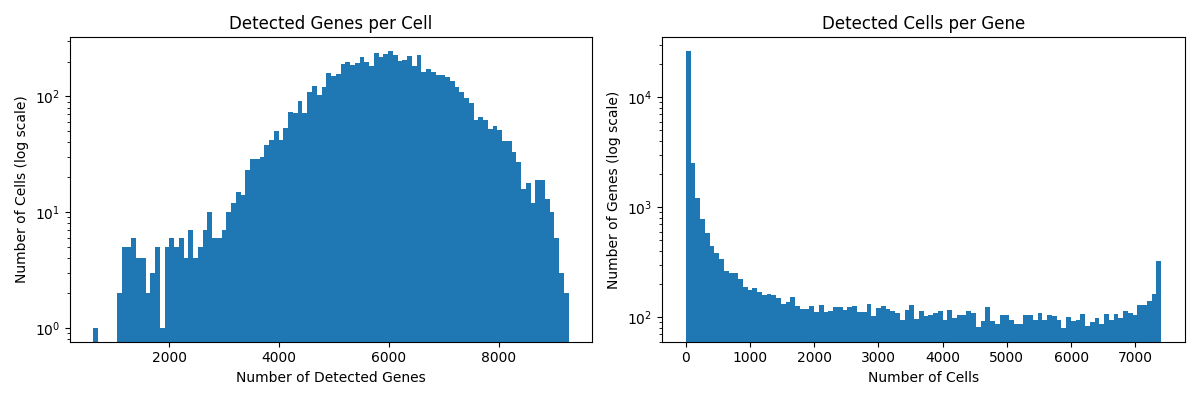

In [7]:
cell_detected_genes = np.asarray((scifate_data_raw.expression_matrix.matrix_sparse > 0).sum(axis=1)).ravel()
gene_detected_cells = np.asarray((scifate_data_raw.expression_matrix.matrix_sparse > 0).sum(axis=0)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cell_detected_genes, bins=100)
axes[0].set_yscale("log")
axes[0].set_title("Detected Genes per Cell")
axes[0].set_xlabel("Number of Detected Genes")
axes[0].set_ylabel("Number of Cells (log scale)")

axes[1].hist(gene_detected_cells, bins=100)
axes[1].set_yscale("log")
axes[1].set_title("Detected Cells per Gene")
axes[1].set_xlabel("Number of Cells")
axes[1].set_ylabel("Number of Genes (log scale)")

plt.tight_layout()
plt.show()

<div style="width: 90%; text-align: justify;">


The two distributions motivate basic filtering steps before further analysis. Based on these diagnostics, cells with too few detected genes and genes detected in too few cells can be removed from the dataset. This reduces noise, decreases computational cost, and prevents rarely observed features or low-quality cells from influencing later steps such as variance-based gene selection, distance computation, and clustering.
</div>

---

## 4.2 Highly Variable Genes

<div style="width: 90%; text-align: justify;">
Single-cell datasets typically contain tens of thousands of genes. However, not all genes contribute equally to the biological differences between cells. Many genes exhibit little variation across the dataset and therefore provide only limited information for downstream analyses. Including all genes may increase computational cost and introduce noise without improving the biological signal. To assess how informative individual genes are, we first examine the distribution of gene variances for both gene expression and NTR data. Genes with high variance are more likely to capture differences between cellular states, whereas genes with low variance often correspond to stable housekeeping functions or measurement noise. Based on these distributions, it is often beneficial to restrict the analysis to the top x most variable genes. The optimal value of x is application-dependent and depends on factors such as the size of the dataset, the biological question, and the downstream method. For example, clustering and dimensionality reduction often benefit from selecting only the most informative genes, whereas other analyses may require a larger fraction of the transcriptome.

</div>

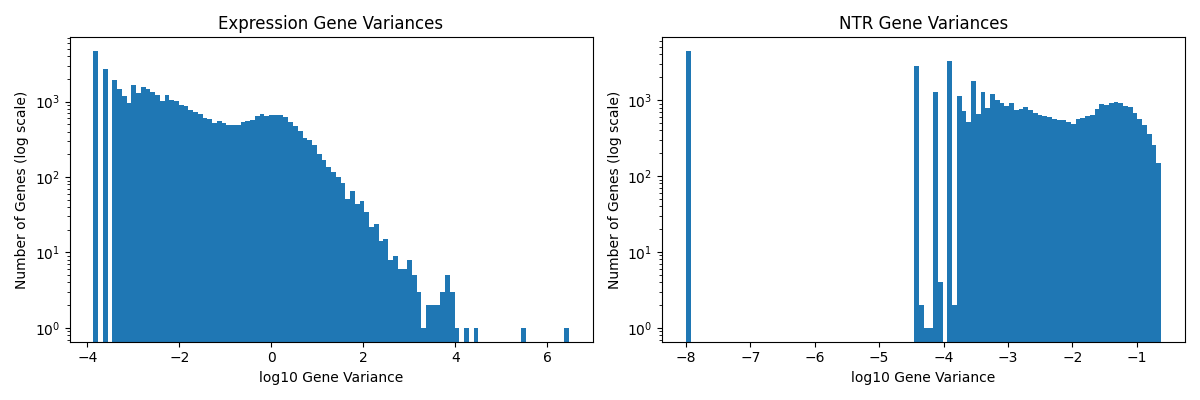

In [8]:
gene_scores_expression = scifate_data_raw.create_gene_variability_scores(data="expression", sort_by="variance")             # data can be "expression" | "ntr" | "new_rna" | "old_rna" 
gene_scores_ntr = scifate_data_raw.create_gene_variability_scores(data="ntr", sort_by="variance")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log10(gene_scores_expression["variance"] + 1e-8), bins=100)
axes[0].set_yscale("log")
axes[0].set_title("Expression Gene Variances")
axes[0].set_xlabel("log10 Gene Variance")
axes[0].set_ylabel("Number of Genes (log scale)")

axes[1].hist(np.log10(gene_scores_ntr["variance"] + 1e-8), bins=100)
axes[1].set_yscale("log")
axes[1].set_title("NTR Gene Variances")
axes[1].set_xlabel("log10 Gene Variance")
axes[1].set_ylabel("Number of Genes (log scale)")

plt.tight_layout()
plt.show()

<div style="width: 90%; text-align: justify;">


Since the majority of genes only show little variation along the observed cells, restricting the analysis to the most variable genes can reduce computational cost, improve the signal-to-noise ratio, and often lead to better clustering and dimensionality reduction results. The exact number of selected genes is not fixed but depends on the dataset and the intended downstream analysis and computational budget. 

<blockquote style="
  color: white;
  background-color: #1f1f2e;
  border-left: 4px solid #352acb;
  padding: 12px;
">
  <strong style="color: #0948d1;">Note:</strong>
  Selecting genes solely based on their variance should be interpreted with caution. Genes with low variance may still carry biologically important information and can be highly relevant for specific downstream tasks such as classification, differential expression analysis, or pathway analysis. The optimal feature selection strategy therefore depends on the scientific question and should not rely exclusively on variance. In the context of this notebook, highly variable genes are primarily used to demonstrate feature selection and to reduce computational complexity for subsequent analyses.
</blockquote>


</div>


--- 
## 4.3 Preprocessing Pipeline in `sciflow`

<div style="width: 90%; text-align: justify;">

The preprocessing pipeline combines the above discosed features like filtering and feature-selection and puts the different steps into a single operation. The parameter `data` specifies which data representation should be processed, while `num_genes` limits the number of retained genes by selecting the most variable ones. The parameter `min_gene_variance` can be used to remove genes that show only little variation across cells. This is useful because genes with very low variance often contribute little to analyses such as clustering or dimensionality reduction while still increasing computational cost. If we set both we can end up with less then `num_genes` because some genes dont have `min_gene_variance`. The parameters `min_genes_per_cell` and `min_cells_per_gene` provide additional quality-control filters. `min_genes_per_cell` can be used to remove cells in which only a small number of genes were detected, whereas `min_cells_per_gene` removes genes that occur in only a small number of cells. Together, these parameters make it possible to reduce the dataset to a smaller and potentially more informative subset before applying downstream analyses.

<blockquote style="
  color: white;
  background-color: #1f1f2e;
  border-left: 4px solid #352acb;
  padding: 12px;
">
  <strong style="color: #0948d1;">Note:</strong>
  The choice of preprocessing parameters can strongly influence both the computational cost and the results of downstream analyses. More restrictive filtering can substantially reduce runtime and memory usage, but may also remove biologically relevant information. Therefore, the parameters should be chosen with the intended downstream analysis and available computational resources in mind.
</blockquote>



</div>



In [9]:
scifate_data = scifate_data_raw.preprocess(
                                    data="expression",                              # selects which data representation is used for preprocessing
                                    num_genes=6_000,                                # keeps at most the 6,000 most variable genes
                                    min_gene_variance=0.05,                         # removes genes with variance below 0.05; may result in fewer than num_genes genes
                                    min_genes_per_cell=None,                        # removes cells with fewer than this number of detected genes; None disables this filter
                                    min_cells_per_gene=None,                        # removes genes detected in fewer than this number of cells; None disables this filter
                                )

Now we can lock at the summary again

In [10]:
print(scifate_data.summary())

ScifateDataset(
  name = SciFateDataset_preprocessed,
  shape = 7404 cells x 6000 genes,
  ntr = yes,
  cell_info = yes,
  gene_info = yes
  trajectory = yes
)


----

In [11]:
# TODO that here is random

For later we already create our plotter object here 

In [12]:
plotter = ScifatePlotter(dataset=scifate_data)


---
---

# 5. Working with the Dataset


<div style="width: 90%; text-align: justify;">

After loading the dataset, the expression matrix, NTR matrix, and metadata can be accessed directly. The expression_matrix and the ntr_matrix are `LabeledSparseMatrix` objects.
The Gene Info and the Cell Info will be `pandas.Dataframes` that contain multible features that represent infos about the rows and columns of the NTR matrix and expression Matrix.
</div>


---

## 5.1 Inspecting the data within the dataset 

Let's look at the gene info (info about the columns of the ntr and expression matrix)

In [13]:
scifate_data.gene_info.head(3)

,gene_id,gene_name,feature_type,region,length
173,ENSG00000197785,ATAD3A,Gene Expression,Exonic (h.ens90),2612
194,ENSG00000189266,PNRC2,Gene Expression,Exonic (h.ens90),2416
211,ENSG00000048707,VPS13D,Gene Expression,Exonic (h.ens90),16320


We can also look at the cell info (info about the rows of the ntr and expression matrix)

In [14]:
scifate_data.cell_info.head(3)

,barcode,cell_line,time,cell_barcode,trajectory
0,A549.4h.AAAAACTCTCTCAA,A549,4h,AAAAACTCTCTCAA,256.0
1,A549.6h.AAAAAAGAAGTTCA,A549,6h,AAAAAAGAAGTTCA,612.0
2,A549.8h.AAAAACGGAGAATA,A549,8h,AAAAACGGAGAATA,2.0


<div style="width: 90%; text-align: justify;">
We can also access the expression_matrix and the NTR matrix in their sparse representation. Instead of storing every matrix entry explicitly, a sparse matrix stores only the non-zero values together with their row and column positions. This is especially useful for single-cell data because most gene-expression values are zero.
</div>

In [15]:
print(scifate_data.expression_matrix.matrix_sparse[30:33, 30:33])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (3, 3)>
  Coords	Values
  (0, 0)	1
  (1, 0)	10
  (1, 1)	2
  (1, 2)	4
  (2, 0)	3
  (2, 1)	2


Or in a rendered dense form, where all matrix entries are displayed explicitly, including zeros, making the values easier to inspect visually.

In [16]:
print(scifate_data.expression_matrix.head(n = 3))

                        ATAD3A  PNRC2  VPS13D
A549.4h.AAAAACTCTCTCAA       1      0       1
A549.6h.AAAAAAGAAGTTCA       2      3       0
A549.8h.AAAAACGGAGAATA       0      0       1


We can also display a compact summary of the LabeledSparseMatrix, which provides an overview of its dimensions, data type, sparsity, view status, and the available row and column metadata.

In [17]:
print(scifate_data.expression_matrix.summary())

LabeledSparseMatrix(
  name=expression_matrix,
  shape=(7404, 6000),
  dtype=int64,
  not_zero=32438855,
  density=73.0210%,
  is_view=True,
  row_info=['barcode', 'cell_line', 'time', 'cell_barcode', 'trajectory'],
  col_info=['gene_id', 'gene_name', 'feature_type', 'region', 'length']
)


---
## 5.2 Working with the data within the dataset 
Because both expression_matrix and ntr_matrix are `LabeledSparseMatrix` objects we can select data by rows and columns to get a new view on the sparse matrix with that we can work.

In [18]:
expression_matrix = scifate_data.expression_matrix

print(f"Type of expression_matrix: {type(expression_matrix)}")

# selecting different properties from the expression matrix
expression_4h = expression_matrix.select_rows(time="4h")

print(f"Type of expression_4h: {type(expression_4h)}")

print()
print(f"Expression Matrix 4h {expression_4h.shape} head:")
print(expression_4h.head(5))

Type of expression_matrix: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>
Type of expression_4h: <class 'sciflow.data.labled_sparse_matrix.LabeledSparseMatrix'>

Expression Matrix 4h (1045, 6000) head:
                        ATAD3A  PNRC2  VPS13D  SAMD11  AGTRAP
A549.4h.AAAAACTCTCTCAA       1      0       1       2       0
A549.4h.AAAACGATCCTGGA       0      1       2       0       0
A549.4h.AAAAATAAGAGGCG       1      1       0       0       0
A549.4h.AAAAGAATCGACGT       2      1       0       0       0
A549.4h.AAAAACTAATTGAG       1      0       0       0       3


Because we get a "new" `LabeledSparseMatrix` from the select we can select even further or chain selection operations.

In [19]:
expression_4h_cells = expression_matrix.select_rows(cell_barcode=["AAAAACTCTCTCAA", "AAAACGATCCTGGA", "AAAAATAAGAGGCG"]).select_cols(gene_id=["ENSG00000225602", "ENSG00000171819", "ENSG00000238173"])

print(expression_4h_cells)

Empty DataFrame
Columns: []
Index: [A549.4h.AAAAACTCTCTCAA, A549.4h.AAAACGATCCTGGA, A549.4h.AAAAATAAGAGGCG]


Now we have three different `LabeledSparseMatrix` but we dont save the matrix and the infos in all of them the selected ones will just be a view of the original  `LabeledSparseMatrix` 

In [20]:
print(f"Same object:                {id(expression_matrix) == id(expression_4h) == id(expression_4h_cells)}")
print("-" * 35)
print(f"Shared matrix object:       {id(expression_matrix._matrix) == id(expression_4h._matrix) == id(expression_4h_cells._matrix)}")
print(f"Shared row_info object:     {id(expression_matrix._row_info) == id(expression_4h._row_info) == id(expression_4h_cells._row_info)}")
print(f"Shared col_info object:     {id(expression_matrix._col_info) == id(expression_4h._col_info) == id(expression_4h_cells._col_info)}")

Same object:                False
-----------------------------------
Shared matrix object:       True
Shared row_info object:     True
Shared col_info object:     True


---
### 5.2.1 Numpy-like indexing

The `LabeledSparseMatrix` also suports NumPy-like indexing. The returned object is again a `LabeledSparseMatrix`, allowing chained selections and preserving all metadata.

Select a single element

In [21]:
expression_matrix_entery = scifate_data.expression_matrix[100,100]

print(expression_matrix_entery)

                        RTCA
A549.0h.CTACCCTGCATCAA     0


Select a single row

In [22]:
expression_matrix_column = scifate_data.expression_matrix[100,:].head(5)

print(expression_matrix_column)

                        ATAD3A  PNRC2  VPS13D  SAMD11  AGTRAP
A549.0h.CTACCCTGCATCAA       3      0       2       0       1


Select a single column

In [23]:

expression_matrix_column = scifate_data.expression_matrix[:,10].head(5)

print(expression_matrix_column)

                        PRDM2
A549.4h.AAAAACTCTCTCAA      0
A549.6h.AAAAAAGAAGTTCA      2
A549.8h.AAAAACGGAGAATA      0
A549.4h.AAAACGATCCTGGA      0
A549.6h.AAAAACTGAATTCC      2


Select with a bolen mask 

In [24]:
mask = (scifate_data.expression_matrix.row_info["time"] == "4h")
expression_matrix_4h = scifate_data.expression_matrix[mask, :]

print(expression_matrix_4h.head(5))

                        ATAD3A  PNRC2  VPS13D  SAMD11  AGTRAP
A549.4h.AAAAACTCTCTCAA       1      0       1       2       0
A549.4h.AAAACGATCCTGGA       0      1       2       0       0
A549.4h.AAAAATAAGAGGCG       1      1       0       0       0
A549.4h.AAAAGAATCGACGT       2      1       0       0       0
A549.4h.AAAAACTAATTGAG       1      0       0       0       3


--- 

### 5.2.2 Working with trajectories

<div style="width: 90%; text-align: justify;">

Besides the expression and NTR matrices, the dataset also contains trajectory information describing temporal relationships between cells across different time points.
These trajectories can be used to directly extract and analyze dynamic expression patterns over time.

</div>



In [25]:
print(f"Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: {scifate_data.get_trajectory_id(barcode="A549.6h.GCGAGGCCTCCATT")}")

Barcode (A549.6h.GCGAGGCCTCCATT) is in trajectory with id: 5


In [26]:
scifate_data.get_trajectory_data(
    trajectory_id=5, 
    data="expression"                       # this can be "epxression" or "ntr" or 'new_rna', or 'old_rna'
).head(5)

,ATAD3A,PNRC2,VPS13D,SAMD11,AGTRAP
A549.0h.CTGTAGGTCTATGG,1,0,0,3,3
A549.2h.ATCTATCTAGGTTC,0,3,0,1,0
A549.4h.GCGGATCCTACCTC,2,1,0,1,1
A549.6h.GCGAGGCCTCCATT,1,0,0,1,2
A549.8h.AAACAACTACCGAC,0,0,2,0,2


In [27]:
scifate_data.get_trajectory_data(
    barcode="A549.4h.GCGGATCCTACCTC",
    data="expression"                       # this can be "epxression" or "ntr" or 'new_rna', or 'old_rna'    
).head(5)

,ATAD3A,PNRC2,VPS13D,SAMD11,AGTRAP
A549.0h.CTGTAGGTCTATGG,1,0,0,3,3
A549.2h.ATCTATCTAGGTTC,0,3,0,1,0
A549.4h.GCGGATCCTACCTC,2,1,0,1,1
A549.6h.GCGAGGCCTCCATT,1,0,0,1,2
A549.8h.AAACAACTACCGAC,0,0,2,0,2


--- 

### 5.2.3 Working with new RNA


In [28]:
scifate_data.get_trajectory_data(
    barcode="A549.4h.GCGGATCCTACCTC",
    data="new_rna"                       # this can be "epxression" or "ntr" or 'new_rna', or 'old_rna'    
).head(5)                                                                                                                                                        

,ATAD3A,PNRC2,VPS13D,SAMD11,AGTRAP
A549.0h.CTGTAGGTCTATGG,0.0,0.0000,0.0,0.0,1.47
A549.2h.ATCTATCTAGGTTC,0.0,2.0805,0.0,0.0,0.00
A549.4h.GCGGATCCTACCTC,0.0,1.0000,0.0,0.0,0.00
A549.6h.GCGAGGCCTCCATT,0.0,0.0000,0.0,0.0,0.00
A549.8h.AAACAACTACCGAC,0.0,0.0000,0.0,0.0,0.00


--- 

### 5.2.4 Working with old RNA


In [29]:
scifate_data.get_trajectory_data(
    barcode="A549.4h.GCGGATCCTACCTC",
    data="old_rna"                       # this can be "epxression" or "ntr" or 'new_rna', or 'old_rna'    
).head(5)  

,ATAD3A,PNRC2,VPS13D,SAMD11,AGTRAP
A549.0h.CTGTAGGTCTATGG,1.0,0.0000,0.0,3.0,1.53
A549.2h.ATCTATCTAGGTTC,0.0,0.9195,0.0,1.0,0.00
A549.4h.GCGGATCCTACCTC,2.0,0.0000,0.0,1.0,1.00
A549.6h.GCGAGGCCTCCATT,1.0,0.0000,0.0,1.0,2.00
A549.8h.AAACAACTACCGAC,0.0,0.0000,2.0,0.0,2.00


---
---
# 6. Distance Analysis on Subsets of the Data

---

### Distance Metrics

<div style="width: 90%; text-align: justify;">

Different biological questions often require different notions of similarity. The package therefore provides multiple interchangeable distance metrics built on top of a shared `BaseDistance` interface.


| Distance Class | Formula | Main Idea | Interpretation for Single-Cell Data | Sparse Support | Important Notes |
|---|---|---|---|---|---|
| `EuclideanDistance` | $\sqrt{\sum_i (x_i-y_i)^2}$ | Measures straight-line distance between two vectors. | Captures absolute expression differences across all features. Cells with similar absolute expression values are close. | Yes | Sensitive to scale and large feature differences. Often useful after normalization or dimensionality reduction. |
| `SquaredEuclideanDistance` | $\sum_i (x_i-y_i)^2$ | Like Euclidean distance, but without the square root. | Strongly emphasizes large expression differences between cells, genes, or trajectories. | No | Not a true metric in the strict mathematical sense because it does not satisfy the triangle inequality. Useful when large deviations should be penalized strongly. |
| `ManhattanDistance` | $\sum_i \|x_i-y_i\|$ | Accumulates absolute element-wise differences. | Measures the total absolute transcriptional difference across all features. | Yes | Often more robust to individual large outliers than Euclidean distance. |
| `CosineDistance` | $1-\frac{x^\top y}{\|x\|\|y\|}$ | Compares vector direction instead of absolute magnitude. | Cells are considered similar if they have similar expression patterns, even if total expression magnitude differs. | Yes | Very useful for high-dimensional expression data where relative pattern is more important than absolute scale. |
| `CorrelationDistance` | $1-\frac{(x-\bar{x})^\top(y-\bar{y})}{\|x-\bar{x}\|\|y-\bar{y}\|}$ | Compares centered expression patterns. | Focuses on relative up/down regulation patterns rather than absolute expression levels. | No | Centering destroys sparsity, therefore this distance internally requires dense representations. Can be expensive for large sparse matrices. |
| `ChebyshevDistance` | $\max_i \|x_i-y_i\|$ | Uses only the largest feature-wise difference. | Two cells are far apart if they differ strongly in at least one feature. | No | Rarely the best default for gene expression data, but useful if the largest single deviation is important. |

</div>






---
## 6.1 The Curse of Dimensionality

<div style="width: 90%; text-align: justify;">

As shown before, single-cell expression data is high-dimensional because each cell is represented by thousands of gene expression values. This high dimensionality contains rich biological information, but it can also make distance-based analysis more difficult. The **curse of dimensionality** describes a collection of problems that occur when data is analyzed in high-dimensional spaces. For distance-based methods, one important effect is **distance concentration**: pairwise distances can become more similar to each other as the number of dimensions increases. This is relevant for single-cell analysis because many downstream methods rely on distances or nearest-neighbor relationships, for example clustering, k-nearest-neighbor graphs, and trajectory analysis. Further reading: [Curse of Dimensionality](https://highdim-book.erhard-lab.de/11_curse_of_dimensionality.html)

#### Distance Concentration in Single-Cell Data

In the context of single-cell expression data, distance concentration would mean that the distances between cells become less clearly distinguishable when more genes are included. If most pairwise distances become very similar, then the distance matrix contains less useful information about local and global structure. This can affect clustering and neighborhood-based methods because it becomes harder to decide which cells are truly close to each other. However, high dimensionality is not automatically bad. If the selected genes contain meaningful biological signal and the distance metric is appropriate, the distance structure can remain informative even in high-dimensional space. Therefore, instead of assuming that the curse of dimensionality affects the dataset, we test it directly on the real Sci-fate expression matrix.

#### Measuring Distance Concentration

To test this, we compute pairwise cell-cell distances using increasing numbers of genes.  
We compare two feature selection strategies:

- highly variable genes
- randomly selected genes

For each number of genes, we calculate the **coefficient of variation** of all pairwise distances:

$ CV = \frac{\text{standard deviation of pairwise distances}}{\text{mean pairwise distance}} $

The coefficient of variation measures how strongly the pairwise distances are spread relative to their average size. A high CV means that distances are broadly distributed and cells remain clearly distinguishable. A low CV means that most distances are similar, which would indicate distance concentration. A strong curse-of-dimensionality effect would therefore be visible if the CV decreases strongly as more genes are included.



</div>




In [30]:
curse_hvg = scifate_data.test_distance_concentration(
    entity="cell",
    data="expression",
    dimensions=[50, 100, 250, 500, 1000, 2000, 5000, 10000, 20000, 30000, 40000],
    metric="cosine",
    feature_strategy="hvg",
)

curse_random = scifate_data.test_distance_concentration(
    entity="cell",
    data="expression",
    dimensions=[50, 100, 250, 500, 1000, 2000, 5000, 10000, 20000, 30000, 40000],
    metric="cosine",
    feature_strategy="random",
);

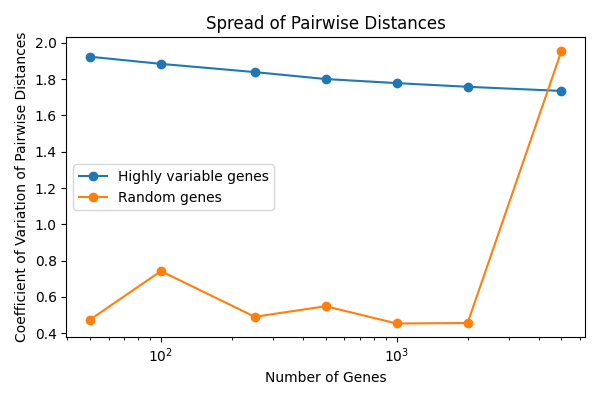

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(curse_hvg["dimension"],curse_hvg["pairwise_distance_cv"],marker="o",label="Highly variable genes",)
ax.plot(curse_random["dimension"],curse_random["pairwise_distance_cv"],marker="o",label="Random genes",)

ax.set_xscale("log")
ax.set_xlabel("Number of Genes")
ax.set_ylabel("Coefficient of Variation of Pairwise Distances")
ax.set_title("Spread of Pairwise Distances")
ax.legend()

plt.tight_layout()
plt.show()

<div style="width: 90%; text-align: justify;">
The results do not show a strong distance concentration effect for the Sci-fate expression data when highly variable genes and cosine distance are used. The nearest/farthest distance ratio remains very small across all tested dimensionalities. This means that nearest neighbors remain clearly distinguishable from farthest neighbors, even when thousands of genes are included. Additionally, the distance spread does not collapse and the coefficient of variation of pairwise distances remains relatively high. This suggests that pairwise distances are still broadly distributed and have not collapsed into a narrow range.

Therefore, the curse of dimensionality is not strongly visible in this specific representation of the dataset.

</div>



---
## 6.2 Calculating and Visualizing the Distance Matrices



Internally, the rows are always interpreted as data points and the columns as features. 

For example:

- cell distances:
  rows = cells, columns = genes

- gene distances:
  rows = genes, columns = cells

- trajectory distances:
  rows = trajectories, columns = concatenated trajectory features

The resulting distance matrices are stored as `LabeledDistanceMatrix` objects and can optionally be cached inside the dataset for later reuse.

---
### <span style="color:lightblue">6.2.1 Distance Matrix of Cells Along a Single Trajectory</span>

<div style="width: 90%; text-align: justify;">

One of the first ways to analyze and better understand the scifate data is to investigate the similarity between different cells. Instead of directly analyzing thousands of individual genes, we can compare entire gene expression profiles between cells and quantify how similar or dissimilar they are to each other. This allows us to identify whether cells share similar transcriptional states, belong to related biological conditions, or follow common developmental processes. To achieve this, pairwise distances between cells can be computed based on their gene expression profiles. The resulting distance matrix provides a compact representation of the relationships between all cells in the dataset and forms the basis for further analyses such as clustering, trajectory validation, and visualization of temporal progression.ore, the curse of dimensionality is not strongly visible in this specific representation of the dataset.

</div>




In [32]:
# Calculate the distance betweean different cells from the same trajectory
expression_cells =  scifate_data.get_trajectory_data(barcode="A549.4h.GCGGATCCTACCTC", data="new_rna")              # This will give us 5 Cells with each 40k genes

cells_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_cells, distance=CorrelationDistance(), entity="cell", data="expression", save=True)

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 714.05it/s]


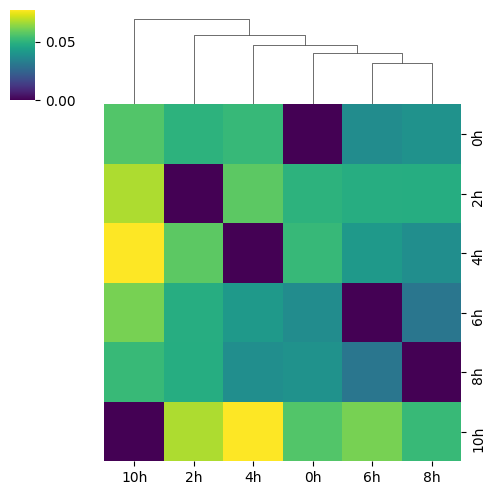

In [33]:
cells_dist_matrix.row_label, cells_dist_matrix.col_label = "time", "time"   

fig =  plotter.plot_distance_matrix(dist_matrix=cells_dist_matrix, cluster_rows=False, cluster_cols=True, figsize=(5,5))

<div style="width: 90%; text-align: justify;">

The hierarchical clustering reorganizes the rows and columns such that transcriptionally similar cells are placed next to each other. The dendrogram therefore visualizes the similarity structure of the trajectory and reveals which time points cluster together based on their global gene expression behavior. In this example, neighboring time points tend to show smaller distances, indicating a gradual temporal progression of the cellular state along the trajectory.

</div>



---
### <span style="color:lightblue">6.2.2 Distance Matrix of Different Genes</span>


<div style="width: 90%; text-align: justify;">


Besides comparing cells, it is also possible to investigate the similarity between genes themselves. Instead of treating cells as observations, the expression profiles of genes across multiple cells are compared to identify genes that exhibit similar transcriptional behavior. Genes with small distances show similar expression patterns across the analyzed cells, which may indicate shared biological functions, co-regulation, or participation in common cellular pathways. In contrast, genes with larger distances behave more independently and may be associated with different biological processes. By computing pairwise distances between genes, the resulting distance matrix captures the global relationship structure between all analyzed genes. Such matrices are useful for identifying groups of co-expressed genes, exploring transcriptional programs, and detecting potential functional relationships between genes.
</div>




In [34]:
# Calculate the distance betweean different genes
expression_genes = scifate_data.expression_matrix[:, [10,20,30,40,50,60]].T                                                                 # here we need to transpose the matrix because we always    
genes_dist_matrix = scifate_data.create_distance_matrix(matrix=expression_genes, distance=ManhattanDistance())

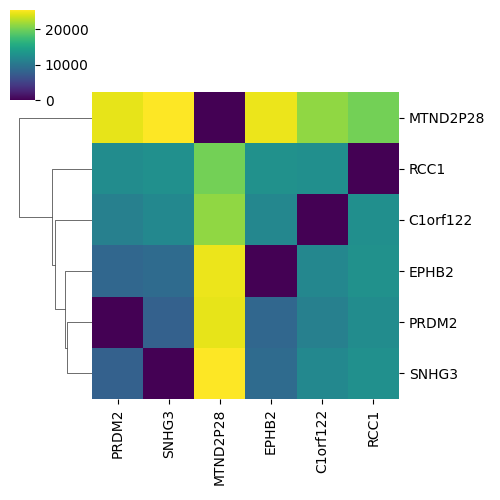

In [35]:
fig = plotter.plot_distance_matrix(dist_matrix=genes_dist_matrix, cluster_rows=True, figsize=(5,5))

---
### <span style="color:lightblue">6.2.3 Distance Matrix of Different Trajectories</span>



<div style="width: 90%; text-align: justify;">

Beyond comparing individual cells or genes, entire trajectories can also be compared with each other. In this setting, each trajectory represents a temporal sequence of cellular states, and the distance matrix measures how similar or dissimilar these overall developmental patterns are. Trajectories with small distances exhibit similar transcriptional dynamics over time, suggesting that they may follow related biological processes or cellular responses. Larger distances indicate stronger differences in temporal gene expression behavior and may point to distinct biological pathways or developmental programs. To compute trajectory-level distances, the expression information of all cells belonging to a trajectory is aggregated into a trajectory representation vector. Pairwise distances between these vectors then provide a compact summary of the relationships between complete trajectories. The resulting distance matrix enables the identification of groups of trajectories with similar temporal behavior and helps to reveal higher-level structures within the dataset.
</div>



In [36]:
# Calculate the distance berwean diveren trajectories 
trajectory_dist_matrix = scifate_data.create_distance_matrix(entity="trajectory", data="expression", distance=CosineDistance())[:20, :20]

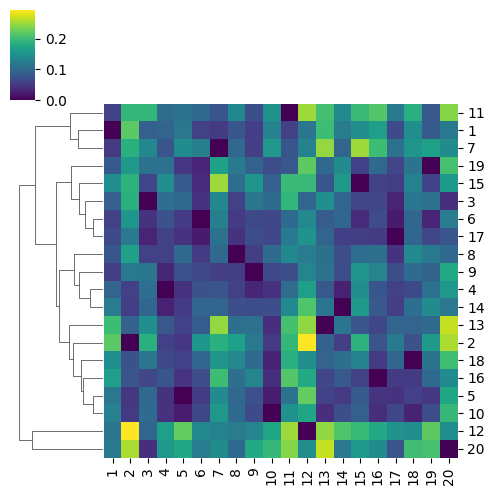

In [37]:
fig =  plotter.plot_distance_matrix(dist_matrix=trajectory_dist_matrix, cluster_cols=False, cluster_rows=True, figsize=(5,5))

---
### <span style="color:lightblue">6.2.4 Distance Matrix of Cells New RNA</span>

<div style="width: 90%; text-align: justify;">

Besides analyzing total gene expression, it is also possible to specifically investigate the similarity between cells based only on newly transcribed RNA. Instead of using the complete expression profiles, the expression counts are weighted by the NTR (new-to-total RNA ratio), resulting in an approximation of the newly synthesized RNA for each gene and cell. This representation focuses on active and recent transcriptional activity rather than accumulated total RNA abundance. As a result, the corresponding distance matrix captures similarities in ongoing gene regulation and dynamic cellular responses. Cells with small distances therefore exhibit similar patterns of newly produced RNA, suggesting comparable current transcriptional programs or biological activity. Larger distances indicate stronger differences in active transcriptional behavior between cells. The clustered distance matrix can help reveal dynamic transcriptional transitions that may not be as visible in the total expression matrix alone.
</div>




In [38]:
new_rna = scifate_data.get_trajectory_data(barcode="A549.4h.GCGGATCCTACCTC", data="new_rna")

new_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=new_rna, 
                                                            distance=CorrelationDistance()
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 1090.00it/s]


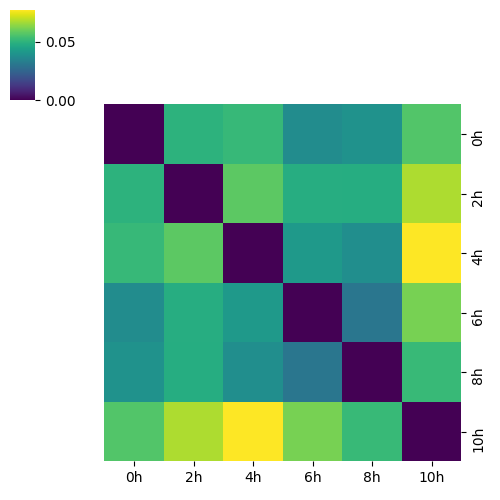

In [39]:
new_rna_dist_matrix.row_label, new_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=new_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

---
### <span style="color:lightblue">6.2.5 Distance Matrix of Cells Old RNA</span>

<div style="width: 90%; text-align: justify;">
In addition to newly synthesized RNA, similarities between cells can also be analyzed based on old RNA. Here, the newly transcribed fraction is subtracted from the total expression profile, resulting in an approximation of the remaining pre-existing RNA within each cell. While new RNA mainly reflects recent transcriptional activity, old RNA captures the more stable and accumulated transcriptional state of the cell. The corresponding distance matrix therefore emphasizes longer-term expression patterns rather than immediate transcriptional changes. Cells with small distances exhibit similar old RNA compositions, indicating comparable persistent cellular states or previously established transcriptional programs. Larger distances suggest stronger differences in the underlying accumulated RNA landscape between cells. Comparing the old RNA distance matrix with the new RNA distance matrix can provide additional biological insight into which similarities arise from stable cellular identity and which are driven by ongoing dynamic transcriptional processes.
</div>



In [40]:
old_rna = scifate_data.get_trajectory_data(barcode="A549.4h.GCGGATCCTACCTC", data="old_rna")

old_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            matrix=old_rna, 
                                                            distance=CorrelationDistance(), 
                                                            entity="cell", 
                                                            data="expression", 
                                                            save=True
                                                        )

CorrelationDistance: 100%|██████████| 1/1 [00:00<00:00, 1150.39it/s]


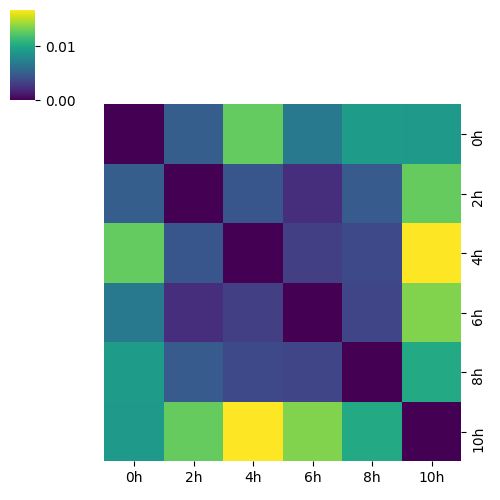

In [41]:
old_rna_dist_matrix.row_label, old_rna_dist_matrix.col_label = "time", "time"                                                                                          
fig =  plotter.plot_distance_matrix(dist_matrix=old_rna_dist_matrix, cluster_cols=False, cluster_rows=False, figsize=(5,5))

---
---
# 7. Distance Matrix on the whole Dataset

<div style="width: 90%; text-align: justify;">
For large single-cell datasets, computing distances between all cells or genes can become expensive very quickly. The reason is that a pairwise distance matrix compares every cell with every other cell. For $n$ cells, this means we need to compute $\frac{n(n-1)}{2}$ unique pairwise distances. In other words, the number of computations grows quadratically with the number of cells. This is still manageable for small datasets, but for larger datasets it can become a major bottleneck. If we want to compute all cell wise distances we would have:
</div>




In [42]:
print("For the cell Distance Matrix we have:")
print(f"Total cells: {scifate_data.expression_matrix.n_rows}")
print(f"Total computations: {scifate_data.expression_matrix.n_rows * (scifate_data.expression_matrix.n_rows - 1) // 2:,}")

print()
print("For the gene Distance Matrix we have:")
print(f"Total genes: {scifate_data.expression_matrix.n_cols}")
print(f"Total computations: {scifate_data.expression_matrix.n_cols * (scifate_data.expression_matrix.n_cols - 1) // 2:,}")

For the cell Distance Matrix we have:
Total cells: 7404
Total computations: 27,405,906

For the gene Distance Matrix we have:
Total genes: 6000
Total computations: 17,997,000


<div style="width: 90%; text-align: justify;">
Even though the number of pairwise comparisons is large, some distance metrics are still practical to compute. This is especially true for distances that can be efficiently vectorized or are implemented in optimized low-level code, for example in NumPy, SciPy, or scikit-learn. Cosine distance is a good example. Instead of manually looping over every pair of cells in Python, we can use an optimized implementation that computes the full pairwise distance matrix much faster. On my Computer it took around 2 Minutes.
</div>

In [43]:
# This will calculate the distance of all cells to each other with the Cosine distance and save it in the scifate dataset
cell_dist_matrix = scifate_data.create_distance_matrix(
                                                            entity="cell",
                                                            data="expression",                               # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                            distance=CosineDistance(),
                                                            save=True
                                                        )

<div style="width: 90%; text-align: justify;">
Euclidean distance can also be computed efficiently on sparse expression matrices. Similar to Cosine distance, highly optimized implementations are available in libraries such as SciPy. Therefore, computing the full Euclidean distance matrix is usually feasible even for larger datasets. On my Computer it took around 2 Minutes.
</div>

In [ ]:
# This will calculate the distance of all cells to each other with the Euclidean Distance and save it in the scifate dataset
new_rna_dist_matrix = scifate_data.create_distance_matrix(
                                                            entity="cell",
                                                            data="expression",                      # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                            distance=EuclideanDistance(),
                                                            save=True
                                                        )

<div style="width: 90%; text-align: justify;">
Once a distance matrix has been computed with `save=True`, it is automatically stored inside the `ScifateDataset`. This avoids the need to recompute expensive distance matrices multiple times and allows them to be reused throughout the analysis workflow. Stored distance matrices can be retrieved at any time using the corresponding entity, data source, and distance metric:
</div>

In [ ]:
new_rna_dist_matrix = scifate_data.get_distance_matrix(
                                                        entity="cell",
                                                        data="expression", 
                                                        distance=EuclideanDistance()
                                                      )

The ploter also knows how to acces them when we provide the same information

In [ ]:
plotter.plot_distance_matrix(
    entity="cell",
    data="expression",
    distance=CosineDistance(),
    n_samples=30
)

<div style="width: 90%; text-align: justify;">
For <strong>Correlation distance</strong> and <strong>Manhattan distance</strong>, computing the full distance matrix is much more expensive. In my case, calculating the full matrix took around <strong>45 minutes</strong>.

The main problem with <strong>Correlation distance</strong> is that it requires <strong>centering each row by subtracting the row mean</strong>. This destroys the sparsity of the expression matrix. A sparse matrix only stores non-zero values, which makes it memory-efficient. However, after subtracting the mean, many previously zero entries become non-zero. As a result, the matrix effectively becomes <strong>dense</strong> and requires much more RAM. Because of this, the <strong>full Correlation distance matrix</strong> cannot be computed efficiently in one step for larger datasets. Instead, the computation has to be done <strong>blockwise</strong>. This avoids loading the full dense matrix into memory at once, but it makes the computation much slower.

For <strong>Manhattan distance</strong>, the problem is different. Although it can be computed on sparse data, it is less efficient for this use case because it depends on the <strong>absolute differences across all genes</strong> for every pair of cells. With many cells and many genes, this leads to a very large number of operations. Therefore, calculating the <strong>full Manhattan distance matrix</strong> for the complete dataset is also very time-consuming.
</div>

---
## 7.1 Scaling Distance Computation with Random Projection

<div style="width: 90%; text-align: justify;">
To address this, random projections can be used to project the data into a lower-dimensional space while still approximately preserving the distances between cells. Under certain conditions, the projected distances remain close to the original distances of the high-dimensional data. This makes it possible to compute distance matrices more efficiently without completely losing the geometric structure of the dataset. One important theoretical foundation is the Johnson–Lindenstrauss lemma. It states that a set of n points can be projected into a significan'tly lower-dimensional space such that pairwise distances are preserved up to a small error. More formally, for an error parameter $\varepsilon \in (0, 1)$, there exists a projection into dimension:

$k = \mathcal{O}\left(\frac{\log n}{\varepsilon^2}\right)$.

such that the distances between all pairs of points are approximately maintained with high probability. This provides the theoretical basis for using random projections in large-scale distance computations. For our dataset and the two aplications of all cell and all gene distances we get.

</div>

In [ ]:
from sciflow.reduction.random_projection import RandomProjektions, jl_dimension, test_random_projection_matrix

In [ ]:
print(f"Cells: {scifate_data.expression_matrix.n_rows:,}")
print(f"Required dimension for cells (eps=0.2): {jl_dimension(scifate_data.expression_matrix.n_rows):,}")

print()

print(f"Genes: {scifate_data.expression_matrix.n_cols:,}")
print(f"Required dimension for genes (eps=0.2): {jl_dimension(scifate_data.expression_matrix.n_cols):,}")

<div style="width: 90%; text-align: justify;">
The Johnson–Lindenstrauss bound provides a theoretical guarantee on the projection dimension required to preserve pairwise distances within a specified error tolerance. However, this bound is generally conservative and represents a worst-case scenario. In practice, much lower projection dimensions are often sufficient to preserve the relevant geometric structure of the data. Therefore, instead of relying solely on the theoretical bound, it is useful to empirically evaluate how well different projection dimensions preserve the original distances. By comparing pairwise distances before and after projection, we can quantify the error introduced by the dimensionality reduction and determine a suitable trade-off between computational efficiency and distance preservation. In the following experiment, random projections with different target dimensions are applied to the dataset. For each projection dimension, the pairwise distances in the projected space are compared to the original distances, and the resulting error is measured. This allows us to assess how much information is lost when reducing the dimensionality and to identify projection dimensions that provide a good approximation of the original distance structure.

</div>

In [ ]:
results = test_random_projection_matrix(
    matrix= scifate_data.expression_matrix.matrix,
    dimensions= [10, 25, 50, 100, 200, 500, 1000, 2000, 3000],
    n_samples= 500,
    metric= "euclidean",
    n_repeats= 5
)

plt.figure(figsize=(6, 4))

plt.plot(
    results["projection_dimension"],
    results["mean_percent_error"],
    marker="o"
)

plt.xlabel("Projection Dimension")
plt.ylabel("Mean Distance Error (%)")
plt.title("Relative Distance Error under Random Projection")
plt.grid(True)

plt.show()


<div style="width: 90%; text-align: justify;">
The previous experiment showed that random projections can preserve the pairwise distances reasonably well even when the data is projected into a much lower-dimensional space. Therefore, random projections can be used as a preprocessing step before computing a distance matrix on the complete dataset. Instead of calculating distances in the original high-dimensional expression space, the data is first projected into a lower-dimensional representation. The distance matrix is then computed using the projected data. This can significan'tly reduce both computation time and memory requirements while still maintaining a good approximation of the original distance structure. In Sciflow, random projections can be passed directly as a dimensionality reduction step when creating a distance matrix. For example, the full cell-cell Euclidean distance matrix can be computed on a randomly projected representation of the expression matrix as follows:


</div>

In [ ]:
new_rna_dist_matrix = scifate_data.create_distance_matrix(
    entity="cell",
    data="expression",                                               # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    distance=CorrelationDistance(),
    reduction=RandomProjektions(
        data_dim=scifate_data.expression_matrix.n_cols,
        feature_dim=500
    ),
    save=True
)

<div style="width: 90%; text-align: justify;">
In this example, the original gene expression vectors are projected to 100 dimensions before the pairwise Euclidean distances are calculated. Depending on the chosen projection dimension, this can lead to substantial speedups while introducing only a small approximation error in the resulting distance matrix. Although random projections are used here as an example, the distance matrix framework is not limited to this particular reduction method. Any dimensionality reduction technique that follows the Sciflow reduction interface can be used in the same way. This includes methods such as PCA, autoencoder-based reductions, and other techniques that will be introduced in Section: 
<span style="color:orange">7. Dimension Reduction and Plotting Data</span>. This makes it possible to experiment with different low-dimensional representations while keeping the distance matrix computation workflow unchanged.

</div>



---


## 7.2 Cell Distance Scores


<div style="width: 90%; text-align: justify;">
A full cell-to-cell distance matrix contains much more information about the data than a heatmap can show. For each cell, we can summarize how far away it is from all other cells or from its local neighborhood. This allows us to identify cells that are transcriptionally unusual compared to the rest of the dataset.

Biologically, cells with high distance scores may represent:

* rare cell states
* transitional cells
* potential outliers
* low-quality cells
* cells from a strongly different time point or condition

Instead of visually inspecting the full distance matrix, we compute summary scores for every cell and sort them by their distance to their nearest neighbors.

</div>



In [ ]:
cell_scores = scifate_data.create_distance_scores(
    entity="cell",
    data="expression",                                           # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    distance=CosineDistance(),
    sort_by="mean_distance"
)

cell_scores.head(5)

<div style="width: 90%; text-align: justify;">
The resulting table ranks all cells according to their average distance to the remaining cells in the dataset. Cells with large mean distances occupy isolated positions in expression space and therefore exhibit transcriptional profiles that differ substantially from the majority of cells. Such cells may represent rare biological states, transitional phenotypes, or technical outliers. 

<br>

To better understand the overall distribution of cell heterogeneity within the dataset, we can visualize the distribution of mean cell distances using a histogram. This allows us to identify whether the dataset contains only a few isolated cells or whether transcriptional diversity is broadly distributed across the population. A long right tail would indicate the presence of highly distinct cells, whereas a narrow distribution would suggest a relatively homogeneous cell population.

</div>



In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    cell_scores["mean_distance"],
    bins=50,
    log=True
)

ax.set_title("Distribution of Mean Cell Distances")
ax.set_xlabel("Mean Distance")
ax.set_ylabel("Number of Cells")

plt.show()

<div style="width: 90%; text-align: justify;">
The distribution of mean cell distances is characterized by a long right tail, indicating that transcriptional heterogeneity is not uniformly distributed across the dataset. While most cells are embedded in dense regions of expression space and exhibit similar transcriptional profiles, a small fraction of cells occupies more distant positions. These cells contribute strongly to the overall variability of the dataset and may represent rare or specialized transcriptional states.
</div>
<br>

<blockquote style="
  color: white;
  background-color: #1f1f2e;
  border-left: 4px solid #352acb;
  padding: 12px;
">
  <strong style="color: #0948d1;">Note:</strong>
  This observation suggests that the population consists primarily of common cellular states accompanied by a smaller number of highly distinct cells.
</blockquote>


---
---
# 8. Clustering Methods

<div style="width: 90%; text-align: justify;">
One of the main goals of single-cell transcriptomics is the identification of groups of cells that share similar transcriptional profiles. Rather than analyzing thousands of cells individually, clustering methods partition the dataset into groups whose members are more similar to each other than to cells belonging to other groups. These groups often correspond to biologically meaningful cell populations, cellular states, developmental stages, or responses to external stimuli.The sciflow framework provides a unified clustering interface that allows different clustering algorithms to be applied to cells, genes, or trajectories while maintaining a consistent workflow.


<br>
<br>

| Clustering Method | Implementation | Main Idea | Important Parameters | Supports Custom Distances | Suitable For | Notes | 
|---|---|---|---|---|---|---| 
| `KMeans` | Self-implemented | Partitions the data into `k` clusters by assigning each point to the nearest cluster center and iteratively updating the centers. | `k`,`optimizer`, `init`, `distance`, `max_steps` | Yes | Fast exploratory clustering of cells, genes, or trajectories | Simple and efficient, but requires a predefined number of clusters and works best for compact, roughly spherical cluster structures. | 
| `HierarchicalClustering` | Framework wrapper | Builds a hierarchy of nested clusters by repeatedly merging similar samples or groups. | `k`, `method`, `metric` | Partially | Exploring hierarchical structure and visualizing cluster relationships | Does not require the cluster structure to be flat from the beginning. The dendrogram can be used to inspect global relationships. | 
| `GraphBasedClustering` | Framework wrapper | Constructs a nearest-neighbor graph and identifies densely connected groups of samples. | `k_neighbors`, `distance`, `resolution` | Yes | Single-cell-style clustering and complex non-spherical structures | Particularly useful for heterogeneous biological data because clusters do not need to be spherical. |

</div>






---
## 8.1 KMeans

<div style="width: 90%; text-align: justify;">


KMeans is one of the most widely used clustering algorithms for exploratory data analysis. The algorithm partitions the data into k clusters by iteratively assigning each data point to its nearest cluster center and updating the cluster centers based on the current assignments. The process continues until the cluster assignments stabilize or a maximum number of iterations is reached. The objective of KMeans is to minimize the within-cluster variance, thereby creating clusters whose members are as similar as possible. Although KMeans assumes approximately spherical cluster structures and requires the number of clusters to be specified beforehand, it often provides a useful first overview of the global structure of high-dimensional biological datasets. If you want to know more about KMeans see:  [KMeans](https://highdim-book.erhard-lab.de/08_KMeans_em.html)

</div>



In [ ]:
kmeans = KMeans(
            k=20,                                       # this can be any int > 1 and is the hart of KMeans
            optimizer="hartigan_wong",                  # this can be "hartigan_wong" or "lloyd"
            init="kmeans++",                            # this can be "forgy" or "random_partition" or "KMeans++"
            distance=EuclideanDistance(),               # this can be any distance Measure that is a BaseDistance() instance
            max_steps=20,                                  
        )

assignments_knn = scifate_data.create_clustering(
                                clustering = kmeans, 
                                entity = "trajectory",                                                                                                  # this can be "cell" or "gene" or "trajectory"
                                data = "expression",                                                                                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                save = True,                                                                                                            # if this is set to True the assignments are saved in the scifate_data object
                                reduction = RandomProjektions(
                                                data_dim=scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],                    # this is just for a speedup to fit the notebook
                                                feature_dim=400
                                            )
                            )

In [ ]:
kmeans = KMeans(
            k=20,                                       # this can be any int > 1 and is the hart of KMeans
            optimizer="hartigan_wong",                  # this can be "hartigan_wong" or "lloyd"
            init="kmeans++",                            # this can be "forgy" or "random_partition" or "KMeans++"
            distance=EuclideanDistance(),               # this can be any distance Measure that is a BaseDistance() instance
            max_steps=20,                                  
        )

assignments_knn = scifate_data.create_clustering(
                                clustering = kmeans, 
                                entity = "trajectory",                                                                                                  # this can be "cell" or "gene" or "trajectory"
                                data = "expression",                                                                                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                save = True,                                                                                                            # if this is set to True the assignments are saved in the scifate_data object
                            )

<div style="width: 90%; text-align: justify;">

The clustering result assigns each trajectory to one of the identified clusters based on the selected distance measure and optimization strategy.
In this example, KMeans is applied to a lower-dimensional representation generated by random projections. Dimensionality reduction can substantially decrease computational cost while preserving much of the underlying structure of the data.
The resulting cluster assignments provide a partitioning of the trajectories into groups with similar expression patterns. However, the cluster labels themselves do not yet reveal whether the identified groups are biologically meaningful or whether the chosen number of clusters is appropriate.

</div>



<div style="width: 90%; text-align: justify;">
While KMeans is simple and computationally efficient, its performance strongly depends on the choice of the number of clusters *k*.
Selecting too few clusters may merge biologically distinct populations, whereas selecting too many clusters can fragment coherent groups into multiple smaller clusters. Consequently, choosing an appropriate value for *k* is an important step in the clustering workflow.
To investigate the effect of different cluster numbers, the `test_ks()` function repeatedly fits KMeans models for a range of candidate values and records the corresponding within-cluster sum of squares (WCSS). The resulting scores can be visualized using an elbow plot. As the number of clusters increases, the score decreases because cluster centers can represent the data more accurately. However, beyond a certain point, adding additional clusters yields only marginal improvements. This region is commonly referred to as the *elbow* and often provides a useful indication of a suitable cluster number.

</div>



In [ ]:
# X, _, _ , _, _= scifate_data._get_entity_vectors(entity="trajectory", data="expression")


# k_scores = KMeans.test_ks(
#     X,
#     reduction = RandomProjektions(
#                                 data_dim=scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],
#                                 feature_dim=500
#                                 ),
#     k_values=range(10, 26, 5)
# )

In [ ]:
# plt.figure(figsize=(5,3))

# plt.plot(
#     k_scores["k"],
#     k_scores["score"],
#     marker="o"
# )

# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Within-cluster sum of squares")
# plt.show()

---
## 8.2 Hierarchical Clustering

<a id="hierarchical_clustering"></a>

<div style="width: 90%; text-align: justify;">
Unlike partitioning methods such as KMeans, hierarchical clustering does not directly produce a fixed set of clusters. Instead, it constructs a hierarchy of nested clusters by repeatedly merging the most similar groups of samples.
The result is represented as a **dendrogram**, a tree-like structure that visualizes the complete clustering process. The leaves of the tree correspond to individual samples, while internal nodes represent cluster merge operations.
The height at which two branches merge corresponds to the distance between the merged clusters. Consequently:

- merges at low heights indicate highly similar samples or clusters,
- merges at large heights indicate strongly separated groups,
- large vertical gaps often suggest natural cluster boundaries.

A major advantage of hierarchical clustering is that the number of clusters does not need to be specified during the clustering process itself. Instead, different clusterings can be obtained by cutting the dendrogram at different heights.
For more inforamtion see: [Hierarchical](https://highdim-book.erhard-lab.de/09_hierarchical.html)

</div>




In [ ]:
hierarchical = HierarchicalClustering(
    k=10,
    method="average",
    metric="euclidean"
)

assignments_hic = scifate_data.create_clustering(
    clustering=hierarchical,                                        
    entity="cell",                                                  # this can be "cell" or "gene" or "trajectory"
    data="expression",                                              # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    save=True,                                                      # if this is set to True the assignments are saved in the scifate_data object and can be acessed by the get assig
    reduction=RandomProjektions(
        data_dim=scifate_data.expression_matrix.n_cols,
        feature_dim=400
    )
)

<div style="width: 90%; text-align: justify;">
For large datasets, the complete dendrogram often becomes difficult to interpret. Therefore, truncated dendrograms are commonly used to visualize only the highest levels of the hierarchy or the final cluster merges. This provides a compact overview of the global cluster structure while preserving the most important relationships between clusters. In the following visualization, the dendrogram is used to examine the hierarchical organization of the clustered samples and to identify major groups as well as potential sub-cluster structures.

</div>





In [ ]:
fig = hierarchical.plot_dendrogram(
    truncate_mode="level",
    p=3,
    figsize=(6, 3)
)

---
## 8.3 Graph-Based Clustering

<div style="width: 90%; text-align: justify;">
Graph-based clustering methods represent the dataset as a graph in which each node corresponds to a cell and edges connect cells with similar expression profiles.
Typically, a k-nearest-neighbor (kNN) graph is constructed from a distance matrix or a low-dimensional embedding. Cells that are close in expression space become connected, while distant cells remain disconnected or weakly connected.
Clustering is then performed directly on the graph structure by identifying densely connected communities. Popular algorithms include Leiden and Louvain clustering, which have become standard approaches in modern single-cell analysis.
Unlike KMeans, graph-based methods do not assume spherical cluster shapes and can capture complex biological structures, making them particularly suitable for heterogeneous cellular populations and developmental trajectories. For more information see: [Graph Based](https://highdim-book.erhard-lab.de/10_graph_based.html)

</div>



In [ ]:
graph_cluster = GraphBasedClustering(
    k_neighbors=10,
    distance=CosineDistance(),
    resolution=1.0,
)

_ = scifate_data.create_clustering(
    clustering = graph_cluster,
    entity = "trajectory",
    data = "expression",                                                                                 # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    reduction = RandomProjektions(
        data_dim = scifate_data.expression_matrix.n_cols * scifate_data.trajectories.shape[1],
        feature_dim = 400
    ),
    save = True
)

after the clustering we can acess the asignment with:

In [ ]:
assignments_graph_based = scifate_data.get_cluster_assignment(
    entity = "trajectory",
    data = "expression",
    reduction = "RandomProjection",
    clustering = "GraphBasedClustering"
)

The graph-based clustering result can be plotted to inspect the learned nearest-neighbor structure. Nodes represent trajectories, and edges connect similar trajectories.

In [ ]:
fig = graph_cluster.plot_graph(
    figsize=(18, 14),
    layout_k=4.0,
    iterations=1000,
    node_size=80,
    edge_alpha=0.15,
    show_node_label=False,
)

---
---
## 8.4 Visualizing Clusters

<div style="width: 90%; text-align: justify;">
After applying a clustering algorithm, the resulting cluster assignments must be examined to determine whether they capture meaningful structure within the data. Numerical clustering metrics alone are often insufficient, as they do not reveal the biological characteristics of the identified groups. Cluster visualizations provide an important link between computational results and biological interpretation. By exploring cluster composition, cluster homogeneity, temporal dynamics, and representative cluster members, it becomes possible to assess whether the clustering reflects meaningful cellular or transcriptional patterns. Depending on the data and clustering method, different visualization strategies can be employed. These include analyses based on cluster sizes, distance matrices, metadata distributions, representative trajectories, and temporal expression patterns. Together, these visualizations provide a comprehensive view of the clustering results and help identify both biologically relevant groups and potential clustering artifacts.


</div>




---
### 8.4.1 Number of Trajectories per Cluster

<div style="width: 90%; text-align: justify;">
One of the first aspects to examine after clustering is the distribution of trajectories across the identified clusters. This provides a simple overview of the clustering result and helps assess whether the partitioning is balanced.
Large clusters may represent common transcriptional programs shared by many trajectories, whereas small clusters can indicate rare cellular states, specialized responses, or potential outliers. Extremely small clusters may also suggest that the selected number of clusters is too large and that the algorithm has fragmented the data into overly specific groups.
By visualizing the number of trajectories assigned to each cluster, we obtain an initial impression of the overall cluster structure before performing more detailed analyses of cluster composition, temporal behavior, and biological characteristics.

</div>



In [ ]:
cluster_sizes = assignments_knn["cluster"].value_counts().sort_index()

plt.figure(figsize=(5, 3))
plt.bar(cluster_sizes.index, cluster_sizes.values)

plt.xlabel("Cluster")
plt.ylabel("Number of Trajectories")
plt.title("Number of Trajectories per Cluster")

plt.tight_layout()
plt.show()

---
### 8.4.2 Distribution of Values within Clusters


<div style="width: 90%; text-align: justify;">
While cluster sizes and cluster-to-cluster distances provide information about the global structure of the clustering, it is also useful to investigate the distribution of values within each cluster.

Two complementary views can be considered:

- **Entity-based distributions**: Each cell, gene, or trajectory is represented by a single summary statistic (for example its mean, median, or total expression). The resulting distribution describes how these aggregated entities are distributed within a cluster.
- **Value-based distributions**: Instead of aggregating entities, all individual values are considered directly. This provides a more detailed view of the underlying expression landscape and allows the identification of sparsity, multimodality, skewness, or heavy-tailed behavior within clusters.

It should be noted that these distributions represent only a **one-dimensional projection** of the data. Relationships between different genes, cells, trajectories, or features are ignored, and therefore important multivariate structures cannot be observed directly. For example, two clusters may exhibit very similar expression distributions while still being clearly separable in a high-dimensional feature space. Despite this limitation, distribution plots remain highly informative. They provide an intuitive summary of cluster composition, reveal potential outliers, identify differences in variability, and help assess whether clusters represent compact and homogeneous groups or highly heterogeneous populations. As a result, they serve as a useful complement to distance-based and high-dimensional visualizations.

</div>



In [ ]:
fig, value_df = plotter.plot_cluster_value_distribution(
    cluster_assignment = assignments_knn,
    entity = "trajectory",
    data = "expression",
    mode="entity",                                                          # this is "entity" or "vlaue"
    aggregation = "mean",                                                   # this is "mean" or "sum" or "median"
    figsize_per_plot = (3,2)
)

---
### 8.4.3 Inter- and Intra-Cluster Distances


<div style="width: 90%; text-align: justify;">
Cluster distance matrices provide a quantitative way to assess both the separation between clusters and the compactness of individual clusters. For two clusters \(C_i\) and \(C_j\), the inter-cluster distance is computed as the mean distance between all points belonging to cluster \(C_i\) and all points belonging to cluster \(C_j\):

$$
d(C_i, C_j) =
\frac{1}{|C_i||C_j|}
\sum_{x \in C_i}
\sum_{y \in C_j}
d(x, y)
$$

When \(i=j\), the same formula describes the intra-cluster distance, which measures the average distance between samples within the same cluster. Large inter-cluster distances indicate that clusters are well separated and represent distinct regions of the data space. Small inter-cluster distances suggest that clusters are similar and may share common biological characteristics. In contrast, small intra-cluster distances indicate compact and homogeneous clusters, whereas large intra-cluster distances suggest greater variability within a cluster.

The resulting cluster distance matrix can be visualized as a heatmap:

- **Diagonal entries** represent intra-cluster distances.
- **Off-diagonal entries** represent inter-cluster distances.

A desirable clustering typically exhibits:

- **small values on the diagonal** (compact clusters),
- **large values off the diagonal** (well-separated clusters).

Such a pattern indicates that samples within a cluster are highly similar to one another while remaining distinct from samples in other clusters.

</div>



In [ ]:
inter_cluster_dist = scifate_data.cluster_distance_matrix(
                                    clustering = "KMeans", 
                                    entity = "trajectory",                                              # this can be "cell" or "gene" or "trajectory"
                                    data = "expression",                                                # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                    reduction = "RandomProjection",                                     # this is to fit the notebook                                        
                                    distance = EuclideanDistance()                                      # this can be any distance class
                                )

In [ ]:
plotter.plot_distance_matrix(dist_matrix=inter_cluster_dist, cluster_cols=False, cluster_rows=False, figsize=(4,4));

---
### 8.4.4 Cluster Network Visualization

<div style="width: 90%; text-align: justify;">
The inter-cluster distance matrix can also be interpreted as a network describing the relationships between clusters. In this representation, each cluster is modeled as a node, while edges connect clusters that are similar to one another according to the selected distance measure. The resulting graph provides a complementary view to the cluster distance heatmap. Whereas the heatmap focuses on pairwise distances, the network emphasizes the overall structure and connectivity of the clustering solution. Typically, clusters that are close in the feature space are connected by stronger edges, while distant clusters are connected by weaker edges or not connected at all. This allows groups of related clusters to emerge naturally as connected regions within the graph. Such a visualization can help answer questions such as:
<br>

- Which clusters are most similar to each other?
- Are there groups of clusters that form larger communities?
- Which clusters occupy isolated regions of the data space?
- Do some clusters appear to bridge otherwise separated groups?

It is important to note that the network representation is derived directly from the cluster distance matrix and therefore depends on the selected distance measure.

</div>




In [ ]:
fig, G = plotter.plot_cluster_network(
    cluster_distance_matrix=inter_cluster_dist,
    k_neighbors=3,
    figsize=(6,4),
    show_edge_labels=False
)

---
### 8.4.5 Mean/Medoid Trajectory over Time

<div style="width: 90%; text-align: justify;">
While cluster distance matrices provide information about the separation between clusters, they do not directly reveal the biological dynamics represented by each cluster of trajectories. To better understand the temporal behavior of the clustered trajectories, we can compute a representative trajectory for every cluster and visualize its development over time.

Several aggregation strategies can be used:

- **Mean**: The average value across all trajectories belonging to a cluster at each time point.
- **Median**: The median value across all trajectories at each time point, providing a more robust estimate that is less sensitive to outliers.
- **Sum**: The total signal across all trajectories within a cluster at each time point.
- **Medoid**: Instead of constructing an artificial average trajectory, the medoid selects the most representative real trajectory within the cluster. The medoid is defined as the trajectory with the smallest average distance to all other trajectories in the same cluster.

The mean, median, and sum aggregations generate synthetic cluster representatives by combining information from multiple trajectories. These summaries provide a smooth overview of the overall cluster behavior and are useful for identifying common temporal trends. In contrast, the medoid corresponds to an actual observed trajectory. This often leads to a more realistic representation of the cluster, especially when trajectories exhibit strong heterogeneity or when averaging would smooth out important biological patterns.

By plotting these representative trajectories over time, it becomes possible to identify characteristic cluster behaviors such as:

- increasing expression over time,
- decreasing expression over time,
- transient activation or repression,
- stable expression profiles,
- delayed responses compared to other clusters.

These trajectory summaries provide an intuitive biological interpretation of the clustering results and help relate cluster structure to temporal cellular dynamics.

</div>



In [ ]:
fig, info_df, representatives = plotter.plot_cluster_trajectories_over_time(
                                                                data = "expression",                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                                clustering = "KMeans",                                  # this can be any clustering alorithm if the assignment exists dataset 
                                                                reduction  = "RandomProjection",
                                                                distance = EuclideanDistance(),
                                                                genes = ["MT-RNR2"],                                    # we will get the expression of all cells from one trajectory for the "MT-RNR2" Gene that is a high variable gene (see above)
                                                                representative_aggregation = "median",                  # this can be "mean" or "sum" or "median" or "medoid" of all our cells corosponding to the trajectory 
                                                                figsize=(10, 6)
                                                            )
fig.show()

In [ ]:
fig, info_df, representatives = plotter.plot_cluster_trajectories_over_time(
                                                                data = "expression",                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
                                                                clustering = "KMeans",
                                                                reduction  = "RandomProjection",
                                                                distance = EuclideanDistance(),
                                                                representative_aggregation = "medoid",                  # this can be "mean" or "sum" or "median" or "medoid"
                                                                genes = None,                                           # we will get the feature_aggregation ("mean") of all genes for the representative because we didnt selected one 
                                                                feature_aggregation="mean",                             # this can be "mean" or "sum" or "median "
                                                                figsize=(10, 6)
                                                            )

fig.show()

---
### 8.4.6 Hierarchical Relationships Between Cluster Representatives

<div style="width: 90%; text-align: justify;">

The previous cluster distance matrix and cluster network already showed how clusters are separated and connected in the feature space. However, one can also use the above computet representative trajectories to create a hiracical clustering.
After computing representative trajectories for each cluster, we can compare these representatives with each other and apply hierarchical clustering to them. This creates a higher-level view of the clustering result: clusters with similar representative time profiles are grouped together in the dendrogram. This is different from the previous cluster network. The network emphasizes the intra and inter cluster distance to measure the similarity betwen clusters, while the dendrogram highlights nested hierarchical relationships between cluster representatives. Biologically, this can be interpreted as grouping related dynamic programs. For example, several smaller clusters may represent different variants of a broader response pattern. The hierarchical clustering can therefore reveal whether some trajectory clusters are subtypes of a larger shared temporal behavior.


</div>



In [ ]:
representatives = scifate_data.create_cluster_representatives(
    clustering = "KMeans",
    reduction = "RandomProjection",
    data = "expression",                                                     # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    aggregation = "mean",                                                    # this can be "median" or "mean" or "sum" or "medioid"
)

In [ ]:
graph_cluster = GraphBasedClustering(k_neighbors=2, distance=EuclideanDistance(), resolution=1.0)
graph_cluster.fit(representatives.to_np())

fig = graph_cluster.plot_graph(
    figsize=(10, 6),
    layout_k=4.0,
    iterations=1000,
    node_size=80,
    edge_alpha=0.15,
    show_node_label=True,
)

---
### 8.4.7 Conclusion of Cluster Representations 

<div style="width: 90%; text-align: justify;">
The visualizations presented throughout this analysis provide valuable insights into the structure and characteristics of the dataset. Distance scores, highly variable genes, cluster sizes, cluster distance matrices, value distributions, and representative trajectories all highlight different aspects of the underlying biological system and help transform high-dimensional data into interpretable summaries.
However, it is important to recognize that nearly all of these visualizations rely on some form of aggregation or projection of the original data. As a result, they provide only a limited view of the underlying high-dimensional structure. Complex relationships between genes, cells, and trajectories are often reduced to a small number of summary statistics, distributions, or pairwise comparisons.
While these visualizations are extremely useful for gaining intuition and understanding the data, they cannot fully capture the structure of the original feature space. Important patterns may therefore remain hidden when the data is viewed only through one-dimensional summaries.

<br>

A natural next step is to apply **dimensionality reduction techniques**, which aim to preserve as much of the original structure as possible while projecting the data into a low-dimensional representation that can be visualized directly. Such approaches make it possible to explore global and local relationships between samples while retaining substantially more information than simple aggregated statistics.
For this reason, the next section focuses on dimensionality reduction methods and their application to the SciFate dataset.
The corresponding analyses are presented in Section 7. Dimension Reduction and Plotting Data

</div>



---
---
# 9. Dimensionality Reduction
---

<div style="width: 90%; text-align: justify;">
The original expression matrix consists of thousands of genes and therefore resides in a very high-dimensional space. While clustering can be performed directly on this data, understanding and interpreting the resulting structure is often challenging. Dimensionality reduction methods project the data into a lower-dimensional space while attempting to preserve important properties of the original dataset.
Different dimensionality reduction techniques focus on preserving different aspects of the data. PCA aims to preserve variance, random projections approximately preserve pairwise distances, and autoencoders learn nonlinear representations directly from the data. Consequently, the same dataset may appear differently depending on the chosen reduction method.

The following dimensionality reduction methods are considered in this notebook:

| Method | Linear | Nonlinear | Preserves Variance | Preserves Distances | Requires Training | Supports Sparse Data |
|----------|----------|----------|----------|----------|----------|----------|
| PCA | Yes | No | Yes | No | No | Partially |
| UMAP | No | Yes | No | Locally, not globally | Yes | Yes |
| Random Projection | Yes | No | No | Yes (approximately) | No | Yes |
| Autoencoder | No | Yes | Learned | Learned | Yes | Yes |


For each dimensionality reduction technique, the resulting low-dimensional embedding is visualized and colored according to the previously computed cluster assignments. These visualizations provide a qualitative assessment of the clustering results and help determine whether clusters form compact groups, overlap with one another, or reveal additional structure that may not be obvious from numerical evaluation alone.

It is important to note that every visualization shown in this section is a projection of a much higher-dimensional dataset. Therefore, some information is inevitably lost during dimensionality reduction, and relationships observed in the visualization may not fully represent the structure of the original data.

</div>



---
## 9.1 Principal Component Analysis (PCA)

<div style="width: 90%; text-align: justify;">

Principal Component Analysis (PCA) is a classical dimensionality reduction technique that projects high-dimensional data onto a smaller set of orthogonal components while preserving as much variance as possible. The resulting principal components are ordered according to the amount of variance they explain. For large and sparse single-cell datasets, computing a full PCA can be computationally expensive. Therefore, this implementation uses **Truncated Singular Value Decomposition (TruncatedSVD)**, which efficiently computes only the most important components and can operate directly on sparse matrices.

Two parameters are distinguished:

* **calculated_components**: number of components computed internally.
* **n_components**: number of components returned in the reduced representation.

This allows the explained variance to be analyzed using many components while still generating a compact embedding for visualization and clustering.
The cumulative explained variance can be used to determine how many principal components are required to retain most of the information contained in the original dataset.

</div>



In [ ]:
pca = PCA(n_components = 3, calculated_components = 100)

pca_matrix = scifate_data.create_reduced_matrix(
    reduction=pca,
    entity="trajectory",                                        # this can be "cell" | "gene" | "trajectory" 
    data="expression",                                          # this can be "expression" | "ntr" | "new_rna" | "old_rna"
    save=True,
)

after the fit we can acces the pca_matrix from the scifate dataset by using this function

In [ ]:
pca_matrix = scifate_data.get_reduced_matrix(
    entity = "trajectory",                                        
    data = "expression",
    reduction = "PCA"
)

The following plot shows the cumulative explained variance of the computed principal components. It helps to assess how many components are needed to capture most of the variance in the original data.

In [ ]:
fig = pca.plot_explained_variance(figsize=(4,3))

<div style="width: 90%; text-align: justify;">
After dimensionality reduction, each cell is represented by three principal components and can therefore be visualized in a three-dimensional space. To evaluate the clustering results, cells are colored according to their graph-based kNN cluster assignments. Cells with similar expression profiles are expected to appear close together in the embedding, while distinct cell populations should form separate groups. Although PCA only provides a linear projection of the original data, it offers a useful overview of the global structure of the dataset and allows the clustering results to be inspected visually.

</div>





In [ ]:
plotter.plot_reduced_matrix(
    pca_matrix,
    dimensions = (0,1,2),
    color_by = assignments_knn["cluster"]                        
)

--- 
## 9.2 UMAP

<div style="width: 90%; text-align: justify;">

Uniform Manifold Approximation and Projection (UMAP) is a nonlinear dimensionality reduction technique that projects high-dimensional data into a lower-dimensional space while preserving the local neighborhood structure of the data. In contrast to PCA, UMAP does not try to preserve global variance. Instead, it constructs a graph of nearest-neighbor relationships in the original feature space and optimizes a low-dimensional embedding that keeps similar points close together.

This implementation is a lightweight wrapper around the `umap-learn` package ([Official documentation](https://umap-learn.readthedocs.io/)), which provides the actual UMAP algorithm and follows a scikit-learn-like API with `fit`, `transform`, and `fit_transform` methods. UMAP can be used for visualization in two or three dimensions, but it can also be used as a general nonlinear dimensionality reduction method before clustering or downstream analysis.

The most important parameters are:

* **n_components**: number of dimensions returned in the reduced representation.
* **n_neighbors**: size of the local neighborhood used to construct the manifold approximation.
* **min_dist**: controls how tightly points are allowed to be packed together in the embedding.
* **metric**: distance metric used to compare points in the original feature space.
* **random_state**: controls reproducibility of the embedding.

A smaller **n_neighbors** value focuses more strongly on local structure, while a larger value includes more global structure. A smaller **min_dist** value produces tighter and more separated clusters, whereas a larger value creates a more spread-out embedding. The official UMAP API describes `n_neighbors` as the size of the local neighborhood used for manifold approximation, while the parameter guide explains that `min_dist` controls how closely points may be packed in the low-dimensional representation. :contentReference[oaicite:1]{index=1}

For large and sparse single-cell datasets, UMAP is especially useful for visualization because it can reveal nonlinear structure, local neighborhoods, clusters, and trajectory-like relationships that may not be visible with linear methods such as PCA. However, UMAP embeddings should be interpreted carefully: distances in the low-dimensional plot do not directly correspond to exact distances in the original space, and global geometry is less reliable than local neighborhood relationships. For more inforamtion see: [Nonlinear embeddings](https://highdim-book.erhard-lab.de/13_nonlinear_embeddings.html)

</div>





UMAP relies on a k-nearest-neighbor graph. By default, the class computes this graph internally from the input data.


In [ ]:
umap_ = UMAP(
    n_components = 3,
    n_neighbors = 30,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42,
    precomputed_knn = None           # if we dont provide a knn graph UMAP will bouild its own graph
)

We can also use a pre computed knn graph from our class that will be used for the umap

In [ ]:
knn_indices, knn_distances = scifate_data.compute_knn_graph(
    entity = "trajectory",                                        # this can be "cell" | "gene" | "trajectory"
    data = "expression",                                          # this can be "expression" | "ntr" | "new_rna" | "old_rna"
    metric = "cosine",
    n_neighbors = 30,
    reduction=PCA(n_components=50)                                # this can be any base reduction class and can be used for more efficency or to reduce noise
)


umap = UMAP(
    n_components = 3,
    n_neighbors = 30,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42,
    precomputed_knn = (knn_indices, knn_distances)           # if we provide a knn graph UMAP will use it
)

In [ ]:
umap_matrix = scifate_data.create_reduced_matrix(
    reduction = umap,
    entity = "trajectory",                                        # this can be "cell" | "gene" | "trajectory"
    data = "expression",                                          # this can be "expression" | "ntr" | "new_rna" | "old_rna"
    save = True,
)

In [ ]:
plotter.plot_reduced_matrix(
    umap_matrix,
    dimensions = (0,1,2)                      
)

---
## 9.3 Autoencoder

<div style="width: 90%; text-align: justify;">
While methods such as PCA and Random Projection perform dimensionality reduction using predefined linear transformations, autoencoders learn a task-specific low-dimensional representation directly from the data.

An autoencoder consists of two neural networks:
- an **encoder**, which compresses the input data into a low-dimensional latent representation,
- a **decoder**, which reconstructs the original data from this latent representation.

During training, the model minimizes the reconstruction error between the original input and the reconstructed output. As a consequence, the encoder learns a compressed representation that preserves the most important information required to reconstruct the data. For this analysis, a deep autoencoder was trained on the cell expression matrix. The encoder gradually reduces the dimensionality from the original gene expression space to a latent representation consisting of only three dimensions:

<p align="center">
  <img src="../assets/autoencoder.png" alt="Banner">
</p>


Several techniques were incorporated to improve the quality and robustness of the learned representation:

- **GELU activations** introduce nonlinearities that allow the model to capture complex biological relationships.
- **Batch normalization** stabilizes training and accelerates convergence.
- **Dropout** reduces overfitting by randomly deactivating neurons during training.
- **Attention layers** in the deeper parts of the encoder allow the model to focus on particularly informative latent features.
- **Sparsity regularization** encourages compact representations and is especially suitable for sparse single-cell expression data.

Unlike PCA, which is restricted to linear transformations, the autoencoder can learn highly nonlinear structures. This makes it possible to capture complex relationships between genes and cells that may not be visible in linear embeddings.
After training, only the encoder part of the network is used. Each cell is mapped into the three-dimensional latent space.

</div>




In [ ]:
autoencoder = Autoencoder(
    input_dim=scifate_data.expression_matrix.n_cols,
    layer_dims=[1024, 256, 128, 16, 3],
    attention_on_layers=[False, False, False, True, True],
    activation="gelu",
    dropout=0.1,
    batch_norm=True,
    learning_rate=1e-3,
    batch_size=256,
    sparsity_loss=True,
    sparsity_weight=1e-4,
    epochs=65
)

In [ ]:
autoencoder.load("../models/autoencoder_cell_expression.pt");
autoencoder.is_fitted = True

autoenc_cell_matrix = scifate_data.create_reduced_matrix(
    reduction= autoencoder,
    entity = "cell",                                            # this can be "cell" | "gene" | "trajectory" 
    data = "expression",                                        # this can be "expression" | "ntr" | "new_rna" | "old_rna"
    save = True,
    save_model = True
)

# autoencoder.save("../models/autoencoder_cell_expression.pt");

--- 
## 9.4 Random Projection

<div style="width: 90%; text-align: justify;">
Unlike PCA or autoencoders, the primary purpose of random projections is not to create a low-dimensional embedding for visualization. Instead, random projections are mainly used to reduce computational complexity while approximately preserving pairwise distances between data points. This makes them particularly useful for large-scale distance calculations and clustering tasks. Nevertheless, the projected data can also be visualized in two or three dimensions. Although such low-dimensional projections preserve the original geometry less accurately than projections with higher target dimensions, they can still provide a useful qualitative impression of the global structure of the dataset. The following plots therefore serve mainly as an exploratory visualization rather than the primary application of random projections.

</div>




In [ ]:
randproj = RandomProjektions(
                        data_dim = scifate_data.expression_matrix.n_cols,
                        feature_dim = 3
                    )

reduced_matrix_rp = scifate_data.create_reduced_matrix(
    reduction= randproj,
    entity = "cell",                                                            # this can be "cell" | "gene" | "trajectory" 
    data = "expression",                                                        # this can be "expression" | "ntr" | "new_rna" | "old_rna"
    save = True
)

In [ ]:
plotter.plot_reduced_matrix(
    reduced_matrix_rp,
    dimensions=(0,1,2),
    color_by= assignments_hic["cluster"]                        
)

---
## 9.5 Visualizing Reduced Representations


### 9.5.1 Visualizing Reduced trajectory matrices

We can look at the visalisation for the different trajectories in 2d

In [ ]:
plotter.plot_reduced_matrix(
    umap_matrix,
    dimensions=(0, 1),
    color_by=assignments_knn["cluster"]
)

We can also color the embedding by **trajectory length**, defined as the sum of the Euclidean distances between consecutive cell in the original space along a trajectory:

$L = \sum_{t=1}^{T-1} \left|x_{t+1} - x_t\right|_2$

A larger value indicates a stronger overall change across the trajectory, while a smaller value represents a more stable trajectory.


In [ ]:
umap_ = UMAP(
    n_components = 3,
    n_neighbors = 30,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42,
    precomputed_knn = None           # if we dont provide a knn graph UMAP will bouild its own graph
)

In [ ]:
plotter.plot_reduced_matrix(
    umap_matrix,
    dimensions = (0, 1),
    color_by = "trajectory_length",
    continuous=True
)

<div style="width: 90%; text-align: justify;">
We can also color trajectories by the **expression of a specific gene**. Since each trajectory contains cells from multiple time points, the gene expression values can be aggregated across the trajectory. For example, using the mean gives the average expression of the selected gene across all cells of a trajectory. This allows us to visualize which regions of the reduced trajectory space are associated with high or low activity of a particular gene. Other aggregation methods, such as the sum, can be used depending on the analysis.

</div>




In [ ]:
plotter.plot_reduced_matrix(
    umap_matrix,
    dimensions = (0, 1),
    entity = "trajectory",
    data = "expression",
    feature = "QSOX2",
    feature_aggregation = "mean",               # can be "mean", "sum", "median", "max", "min"
    continuous=True
)

We can also look at the visalisation for the different trajectories in 3d

In [ ]:
plotter.plot_reduced_matrix(
    umap_matrix,
    dimensions=(0, 1, 2),
    color_by = assignments_knn["cluster"]
)

---
### 9.5.2 Visualizing Reduced Cell Representations

The reduced cell-expression matrices can be visualized in two or three dimensions. Points can be colored in several ways:

* by metadata stored in `row_info`, such as `time`, `cell_line`, or `trajectory`,
* by externally computed assignments, such as clustering labels,
* by the value of a feature from the original expression matrix for example a specific gene.

This makes it possible to compare the geometric structure produced by dimensionality reduction with biological or computational annotations of the cells.


#### Coloring by Cell Metadata

The reduced cell representation can be colored using information stored for each cell, such as `trajectory` or  `time`. This helps relate the structure of the reduced space to known biological or experimental information.


In [ ]:
plotter.plot_reduced_matrix(
    autoenc_cell_matrix,
    dimensions=(0, 1, 2),
    color_by = "trajectory",                # this can be "trajectory", a assignment in the form of a np.array, or a row_info column name like "barcode" or "cell_line"	or "time" or "cell_barcode"  
    entity = "cell",
    continuous=True
)

In [ ]:
plotter.plot_reduced_matrix(
    autoenc_cell_matrix,
    dimensions=(0, 1, 2),
    color_by = "time",                # this can be "trajectory", a assignment in the form of a np.array, or a row_info column name like "barcode" or "cell_line" or "time" or "cell_barcode"  
    entity = "cell"
)

#### Coloring by Gene Expression

Reduced representations can also be colored by the expression of a selected gene from the original high-dimensional matrix. Here, the cells are colored according to **QSOX2** expression. The coordinates come from the reduced representation, while the color represents the original expression value of the gene. This allows us to examine whether the expression of a biologically relevant feature is associated with particular regions or structures in the reduced space.


In [ ]:
plotter.plot_reduced_matrix(
    autoenc_cell_matrix,
    dimensions = (0, 1, 2),
    entity = "cell",
    data = "expression",
    feature = "QSOX2",
    feature_aggregation = "mean",
    continuous=True
)

#### Coloring by Cluster Assignment

The reduced representation can also be colored using externally computed labels, such as the cluster assignments obtained from hierarchical clustering. This makes it possible to directly inspect how the detected clusters are distributed in the reduced space.


In [ ]:
plotter.plot_reduced_matrix(
    autoenc_cell_matrix,
    dimensions = (0,1,2),
    color_by = assignments_hic["cluster"]         # this can be "trajectory", a assignment in the form of a np.array, or a row_info column name like "barcode" or "cell_line"	or "time" or "cell_barcode"               
)

---
---
# 10. Comparing Analysis Workflows


<div style="width: 90%; text-align: justify;">

The previous sections introduced the individual building blocks of the analysis, including dimensionality reduction, distance calculation, and clustering. In this section, these components are combined into different workflows and the resulting clustering structures are compared.

The goal is to investigate how sensitive the analysis is to methodological choices and to determine which structures remain stable across different data representations and processing strategies. To compare clustering results, we first introduce several comparison measures, including overlap matrices, the Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI).

We then use these measures to investigate several aspects of the analysis:

<ul>
<li>whether clustering before and after dimensionality reduction produces similar groups,</li>
<li>whether total RNA and newly synthesized RNA reveal similar clustering structures,</li>
<li>how the order of dimensionality reduction and trajectory construction influences trajectory clustering,</li>
<li>and whether PCA can improve clustering robustness by reducing artificially introduced noise.</li>
</ul>

Rather than identifying a single universally optimal workflow, these comparisons provide an exploratory view of how different analytical decisions influence the structures detected in the Sci-fate dataset.

</div>


---
## 10.1 Comparing Clustering Results

<div style="width: 90%; text-align: justify;">

Before comparing the different analysis workflows, we first need suitable measures to quantify how similar or different their results are. Since many of the workflows considered in this section produce clustering assignments, we begin by introducing several methods for comparing clustering results. These measures allow us to determine whether two workflows recover similar groups of cells or trajectories, or whether changes in the analysis pipeline lead to substantially different clustering structures.

We first consider an overlap matrix for a direct cluster-by-cluster comparison, followed by the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), which summarize the agreement between two clusterings numerically.

</div>


In [ ]:
from sciflow.cluster.compare import clustering_overlap_matrix, adjusted_rand_index, normalized_mutual_information

---
### 10.1.1 Overlap Matrix

<div style="width: 90%; text-align: justify;">

An overlap matrix provides a direct way to compare two clustering results by counting how observations from one clustering are distributed across the clusters of another. Each row represents a cluster from the first clustering, while each column represents a cluster from the second clustering. The matrix therefore shows which clusters correspond closely to each other and where clusters are split or merged between the two results.

To first demonstrate how the clustering comparison using the Overlap Matrix works, we compare the KNN-based and graph-based clustering results, which both assign cluster labels to the same trajectories based on their gene-expression profiles.

</div>




In [ ]:
contingency_total_vs_new = clustering_overlap_matrix(
    assignments_knn,
    assignments_graph_based,
    normalize="rows",
    id_col="trajectory_id",
    name_a="HIC Clustering after PCA",
    name_b="HIC Clustering before PCA"
)

plotter.plot_matrix(matrix=contingency_total_vs_new);

<div style="width: 90%; text-align: justify;">

The overlap matrix can now be used to inspect how the KNN-based trajectory clustering relates to the graph-based trajectory clustering. Each row shows how one cluster from the KNN-based clustering is distributed across the clusters obtained with the graph-based method. A strong concentration of values in a single column indicates that the corresponding KNN cluster largely matches one graph-based cluster, suggesting that both methods identify a similar group of trajectories. If a row is spread across several columns, this indicates that trajectories grouped together by the KNN-based method are distributed across multiple graph-based clusters. Conversely, if several rows have their strongest overlap with the same column, this suggests that trajectories separated into different KNN clusters are grouped together by the graph-based method.

<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
  The overlap matrix shows how consistently the two clustering methods group the same trajectories. Concentrated overlaps indicate similar cluster structures, while distributed overlaps reveal trajectories whose assignments depend more strongly on the chosen clustering method.
</blockquote>

</div>





---
### 10.1.2 Adjusted Rand Index


<div style="width: 90%; text-align: justify;">

While the overlap matrix gives a detailed cluster-by-cluster comparison, it is also useful to summarize the similarity between two clusterings with a single numerical score. For this, we use the Adjusted Rand Index (ARI). The Rand Index compares two clusterings by looking at pairs of observations. For every pair of cells or trajectories, it checks whether the two observations are assigned to the same cluster or to different clusters in both clustering results. If many pairs receive the same relationship in both clusterings, the two clusterings are considered similar. However, the normal Rand Index can be high even if two clusterings agree partly by random chance. The Adjusted Rand Index corrects for this expected random agreement, making it more suitable for comparing clustering results.

The ARI has an intuitive interpretation:

ARI = 1 means that both clusterings are identical, except for possible differences in the numerical cluster labels.
ARI ≈ 0 means that the agreement between the two clusterings is close to what would be expected by random chance.
ARI < 0 means that the agreement is worse than expected by random chance.

Here, we use the ARI to quantify the agreement between the KNN-based and graph-based trajectory clusterings introduced above. A high ARI indicates that both methods assign pairs of trajectories to similar groups, whereas a low ARI indicates that the resulting cluster structures differ substantially between the two clustering approaches.

This is also better because it keeps 10.1 purely about introducing comparison measures. Later, when you actually compare PCA vs. no PCA, total vs. new RNA, etc., you can reuse ARI without redefining its interpretation each time.

</div>




In [ ]:
ari = adjusted_rand_index(
    assignments_knn,
    assignments_graph_based,
    id_col="trajectory_id",
)

print(f"ARI for the assignment of HIC before and after PCA: {ari:.4f}")

<div style="width: 90%; text-align: justify;">

<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
  The Adjusted Rand Index measures how similarly two clustering methods group pairs of observations while correcting for agreement expected by chance. Values close to 1 indicate highly similar clusterings, whereas values around 0 indicate little agreement beyond chance.
</blockquote>
</div>





---
### 10.1.3 Normalized Mutual Information

<div style="width: 90%; text-align: justify;">

In addition to the Adjusted Rand Index, we also use Normalized Mutual Information (NMI) to compare two clustering results. Mutual Information measures how much information one clustering provides about the other clustering. In this context, it asks: if we know the cluster assignment of a cell or trajectory in one clustering, how much does that help us predict its cluster assignment in the other clustering? The normalized version rescales this value to make it easier to interpret. NMI usually ranges between 0 and 1 where NMI = 1 means that both clusterings contain the same information about the grouping structure and NMI = 0 means that knowing one clustering gives no information about the other clustering.
Higher NMI values indicate stronger agreement between the two clustering results. Compared to the ARI, NMI is often more tolerant when one clustering splits a cluster into several smaller clusters. This is because NMI focuses on shared information rather than exact pairwise agreement. Therefore, ARI and NMI provide complementary views of clustering similarity.

Here, we use NMI to quantify how much grouping information is shared between the KNN-based and graph-based trajectory clusterings introduced above. A high NMI indicates that both methods capture a similar overall grouping structure, while a low NMI indicates that the information contained in the two cluster assignments differs substantially.

</div>





In [ ]:
nmi = normalized_mutual_information(
    assignments_knn,
    assignments_graph_based,
    id_col="trajectory_id",
)

print(f"NMI for the assignment of HIC before and after PCA: {nmi:.4f}")

<div style="width: 90%; text-align: justify;">

<blockquote style="
  color: white;
  background-color: #3f6a335c;
  border-left: 4px solid #059f0d6e;
  padding: 12px;
">
  <strong style="color: #2e7d32;">Summary:</strong>
   Normalized Mutual Information measures how much grouping information is shared between two clustering results. Values close to 1 indicate that both clusterings contain very similar grouping information, whereas values close to 0 indicate little shared information.
</blockquote>
</div>





---
## 10.2 Effect of Dimensionality Reduction on Clustering

<div style="width: 90%; text-align: justify;">

Dimensionality reduction is often applied before clustering to reduce computational cost and suppress less informative variation in high-dimensional data. However, reducing the dimensionality also changes the representation on which the clustering algorithm operates. It is therefore important to investigate whether the main grouping structure of the data is preserved after this transformation. In this section, we compare hierarchical clustering performed directly on the original gene-expression data with hierarchical clustering performed after PCA. Both workflows use the same clustering algorithm and differ only in whether dimensionality reduction is applied beforehand. This allows us to isolate the effect of PCA on the resulting cluster assignments.

The comparison is evaluated visually and quantitatively using the methods introduced in Section 10.1: an overlap matrix, the Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI).
 
We first create a second hierarchical clustering in which PCA is applied before clustering. The original expression profiles are reduced to three principal components, and the hierarchical clustering algorithm is then applied to this reduced representation.
</div>

In [ ]:
hierarchical = HierarchicalClustering(
    k = 10,
    method = "average",
    metric = "euclidean"
)

assignments_hic_pca = scifate_data.create_clustering(
    reduction = PCA(n_components = 3, calculated_components = 100),     # here we will provide our reduction method that will be aplid to the data bevor clustering
    clustering = hierarchical,                                          # here again we can use any clustering method that we want 
    entity = "cell",                                                    # this can be "cell" or "gene" or "trajectory"
    data = "expression",                                                # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    save = True,
)

<div style="width: 90%; text-align: justify;">

As a first qualitative comparison, we visualize the cluster assignments obtained before and after PCA in the same reduced space. This makes it possible to inspect whether similar regions of the expression space are assigned to the same clusters in both workflows.
</div>

In [ ]:
plotter.plot_reduced_comparison(
    reduced_matrix=autoenc_cell_matrix,
    color_by=assignments_hic["cluster"],
    compare_color_by=assignments_hic_pca["cluster"],
    dimensions=(0,1),
    titles=("Clustering before reduction", "Clustering after reduction")
)

<div style="width: 90%; text-align: justify;">

To inspect the correspondence between individual clusters more directly, we compute the overlap matrix between the clustering obtained after PCA and the clustering obtained from the original expression data.

</div>

In [ ]:
contingency_before_vs_after_pca = clustering_overlap_matrix(
    assignments_hic_pca,
    assignments_hic,
    normalize="rows",
    id_col="barcode",
    name_a="HIC Clustering after PCA",
    name_b="HIC Clustering before PCA"
)

plotter.plot_matrix(matrix=contingency_before_vs_after_pca);


<div style="width: 90%; text-align: justify;">

A concentrated overlap indicates that a cluster obtained after PCA corresponds closely to one cluster from the original high-dimensional representation. More distributed overlaps indicate that PCA changes the grouping structure, for example by merging observations that were previously separated or by splitting an existing cluster into multiple groups.

</div>

<div style="width: 90%; text-align: justify;">

While the overlap matrix provides a cluster-level view, ARI and NMI summarize the overall similarity between the two clustering results. The ARI measures agreement in pairwise cluster assignments, whereas NMI measures how much grouping information is shared between both clusterings.

</div>

In [ ]:
ari = adjusted_rand_index(
    assignments_hic_pca,
    assignments_hic,
    id_col="barcode",
)

print(f"ARI for the assignment of HIC before and after PCA: {ari:.4f}")

In [ ]:
nmi = normalized_mutual_information(
    assignments_hic_pca,
    assignments_hic,
    id_col="barcode",
)

print(f"NMI for the assignment of HIC before and after PCA: {nmi:.4f}")

<blockquote style="
  color: white;
  background-color: #a223785c;
  border-left: 4px solid #9f05856e;
  padding: 12px;
">
  <strong style="color: #c750b7;">Result:</strong>
    The clustering obtained after PCA remains reasonably similar to the clustering performed in the original expression space, with an ARI of 0.616 and an NMI of 0.686. This suggests that PCA preserves a substantial part of the original grouping structure while still changing some cluster assignments.
</blockquote>

---
### 10.2.1 Sensitivity to the Number of PCA Components

<div style="width: 90%; text-align: justify;">

The previous comparison uses a fixed number of principal components. However, the amount of information retained by PCA depends directly on the chosen dimensionality. Using very few components may discard biologically relevant structure, while using more components retains more of the original variation but provides less dimensionality reduction.

To investigate how sensitive the clustering result is to this choice, we repeat the PCA-based clustering using different numbers of principal components and compare each result with the clustering obtained from the original expression data using ARI and NMI.

</div>

In [ ]:
# pca_components = [2, 3, 5, 10, 20, 30]
# results = []

# for n_components in pca_components:
#     print(f"Running clustering with {n_components} PCA components...")

#     hierarchical = HierarchicalClustering(k=10,method="average",metric="euclidean")
#     pca = PCA(n_components=n_components,calculated_components=max(100, n_components))

#     assignments_hic_pca = scifate_data.create_clustering(reduction=pca, clustering=hierarchical, entity="cell", data="expression", save=False)

#     ari = adjusted_rand_index(assignments_hic_pca, assignments_hic, id_col="barcode")
#     nmi = normalized_mutual_information(assignments_hic_pca, assignments_hic, id_col="barcode",)

#     results.append({"n_pca_components": n_components, "ARI": ari, "NMI": nmi})

# pca_comparison = pd.DataFrame(results)

# fig, ax = plt.subplots(figsize=(8, 5))

# ax.plot( pca_comparison["n_pca_components"], pca_comparison["ARI"], marker="o", label="ARI",)
# ax.plot(pca_comparison["n_pca_components"],pca_comparison["NMI"],marker="o",label="NMI",)

# ax.set_xlabel("Number of PCA components")
# ax.set_ylabel("Clustering similarity")
# ax.set_title("Effect of PCA dimensionality on clustering similarity")
# ax.legend()

# fig.show()

<div style="width: 90%; text-align: justify;">

If ARI and NMI increase as more principal components are retained, this suggests that additional components contain information that is important for reproducing the original clustering structure. If the scores reach a plateau, this indicates that adding further components contributes little additional clustering information.

<blockquote style="
  color: white;
  background-color: #a223785c;
  border-left: 4px solid #9f05856e;
  padding: 12px;
">
  <strong style="color: #c750b7;">Result:</strong>
    The number of retained PCA components controls the trade-off between dimensionality reduction and preservation of the original clustering structure. Comparing ARI and NMI across different component counts helps identify how much dimensionality can be removed before the clustering changes substantially.
</blockquote>

</div>

---
## 10.3 Comparing Clustering Results Between Total RNA and New RNA

<div style="width: 90%; text-align: justify;">

Sci-fate provides information about both the total amount of RNA present in each cell and the RNA that was newly synthesized during the labeling period. These two representations capture different aspects of cellular state: total RNA reflects the accumulated transcriptional state of the cell, whereas new RNA provides information about more recent transcriptional activity. To investigate whether these two representations reveal similar cellular structures, we perform the same hierarchical clustering workflow on the newly synthesized RNA data and compare the resulting cluster assignments with those obtained from the total RNA expression data. PCA is applied before clustering in order to reduce the dimensionality of the input while keeping the clustering procedure otherwise comparable.

</div>

In [ ]:
hierarchical = HierarchicalClustering(
    k = 10,
    method = "average",
    metric = "euclidean"
)

assignments_hic_new_rna = scifate_data.create_clustering(
    reduction = PCA(n_components = 20, calculated_components = 100),    # here we will provide our reduction method that will be aplid to the data bevor clustering
    clustering = hierarchical,                                          # here again we can use any clustering method that we want 
    entity = "cell",                                                    # this can be "cell" or "gene" or "trajectory"
    data = "new_rna",                                                   # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    save = True,
)

<div style="width: 90%; text-align: justify;">

We first compare the two clustering results using the overlap matrix introduced in Section 10.1. This allows us to inspect which clusters obtained from new RNA correspond to clusters derived from total RNA and where the two representations lead to different groupings of cells.

</div>

In [ ]:
contingency_total_vs_new = clustering_overlap_matrix(
    assignments_hic_new_rna,
    assignments_hic,
    normalize="rows",
    id_col="barcode",
    name_a="HIC Clustering with new RNA",
    name_b="HIC Clustering with total RNA"
)

plotter.plot_matrix(matrix=contingency_total_vs_new);


<div style="width: 90%; text-align: justify;">

To summarize the overall agreement between both clustering results, we additionally calculate the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI). These measures quantify how strongly the grouping structure obtained from new RNA agrees with the structure obtained from total RNA.

</div>

In [ ]:
ari_new_total = adjusted_rand_index(assignments_hic_new_rna, assignments_hic, id_col="barcode")
nmi_new_total = normalized_mutual_information(assignments_hic_new_rna, assignments_hic, id_col="barcode")

print(f"NMI for the assignment of HIC with new RNA: {nmi_new_total:.4f}")
print(f"ARI for the assignment of HIC total RNA: {ari_new_total:.4f}")

<div style="width: 90%; text-align: justify;">

<blockquote style="
  color: white;
  background-color: #a223785c;
  border-left: 4px solid #9f05856e;
  padding: 12px;
">
  <strong style="color: #c750b7;">Result:</strong>
    The comparison between total RNA and newly synthesized RNA shows how strongly the inferred cellular grouping depends on the RNA representation. Higher agreement would indicate that both representations capture similar cellular states, whereas lower agreement would suggest that recent transcriptional activity reveals additional structure not present in total RNA alone.
</blockquote>


</div>

---
## 10.4 Effect of Reduction Order on Trajectory Clustering

<div style="width: 90%; text-align: justify;">

When trajectories are used as observations, dimensionality reduction can be applied at two different stages of the analysis. PCA can either be applied after the cell profiles have been combined into complete trajectory representations, or it can be applied to the individual cells before the reduced cell representations are concatenated into trajectories.

These two approaches differ in what PCA is allowed to capture. In the <strong>trajectory-first</strong> workflow, PCA operates on the complete trajectory representation and can therefore capture variation across the full temporal sequence. In the <strong>cell-first</strong> workflow, PCA first compresses each individual cell state, and trajectories are subsequently represented by concatenating these reduced cell representations.

We therefore compare the following workflows:

<table style="border-collapse: collapse;">
  <tr>
    <td style="padding-right: 20px;"><strong>Trajectory-first PCA:</strong></td>
    <td>Cells → Trajectory → PCA → Clustering</td>
  </tr>
  <tr>
    <td style="padding-right: 20px;"><strong>Cell-first PCA:</strong></td>
    <td>Cells → PCA → Trajectory → Clustering</td>
  </tr>
</table>


Both workflows use the same expression data, number of PCA components, and KMeans clustering configuration. This allows us to investigate specifically how the position of the dimensionality-reduction step influences the resulting trajectory clusters.

</div>

<div style="width: 90%; text-align: justify;">

In the trajectory-first workflow, the expression profiles of the ordered cells are first concatenated into one trajectory-level representation. PCA is then applied to these complete trajectory vectors before KMeans clustering is performed.

</div>

In [ ]:
# for the first workflow we can do everything like before 
trajectory_first = scifate_data.create_clustering(
    clustering=KMeans(
        k=20,
        optimizer="hartigan_wong",
        init="KMeans++",
        distance=EuclideanDistance(),
        max_steps=20,
    ),
    entity="trajectory",                                                                # by providing trajectory here we will concat the original cells along side the trajectories and then use Cells -> Trajectory -> PCA -> Clustering 
    data="expression",                                                                  # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    reduction=PCA(n_components=20, calculated_components=100),
    save=False,
)

<div style="width: 90%; text-align: justify;">

In the cell-first workflow, PCA is applied to the expression profile of each individual cell first. The resulting low-dimensional cell representations are then concatenated according to the trajectory structure, and KMeans clustering is performed on these reduced trajectory representations.

</div>

In [ ]:
# for the first workflow we can do everything like before 
pca_first = scifate_data.create_clustering(
    clustering=KMeans(
        k=20,
        optimizer="hartigan_wong",
        init="kmeans++",
        distance=EuclideanDistance(),
        max_steps=20,
    ),
    entity="trajectory",                                                               # by providing trajectory here we will concat the original cells along side the trajectories and then use Cells -> Trajectory -> PCA -> Clustering 
    data="expression",                                                                 # this can be "expression" or "ntr" or "new_rna" or "old_rna"
    cell_reduction=PCA(n_components=20, calculated_components=100),                     
    save=False
)

<div style="width: 90%; text-align: justify;">

To determine whether the order of dimensionality reduction changes the resulting trajectory structure, we first compare the two cluster assignments using an overlap matrix. This shows how trajectories assigned to one cluster in the cell-first workflow are distributed across the clusters obtained with the trajectory-first workflow.

</div>

In [ ]:
contingency_matrix_first = clustering_overlap_matrix(
    pca_first,                                  
    trajectory_first,
    normalize="rows",
    id_col="trajectory_id",
    name_a="Cell-first PCA",
    name_b="Trajectory-first PCA"
)

plotter.plot_matrix(matrix=contingency_matrix_first);

<div style="width: 90%; text-align: justify;">

We additionally calculate ARI and NMI to summarize the overall similarity between the two trajectory clusterings. High values indicate that the order of PCA and trajectory construction has little influence on the resulting groups, whereas lower values indicate that the two workflows capture different trajectory structures.
</div>

In [ ]:
ari_pca_order = adjusted_rand_index(pca_first, trajectory_first, id_col="trajectory_id")
nmi_pca_order = normalized_mutual_information(pca_first, trajectory_first, id_col="trajectory_id")

print(f"ARI between cell-first and trajectory-first PCA: {ari_pca_order:.4f}")
print(f"NMI between cell-first and trajectory-first PCA: {nmi_pca_order:.4f}")


<div style="width: 90%; text-align: justify;">

<blockquote style="
  color: white;
  background-color: #a223785c;
  border-left: 4px solid #9f05856e;
  padding: 12px;
">
  <strong style="color: #c750b7;">Result:</strong>
    
</blockquote>


</div>


---
## 10.5 Evaluating PCA as a Noise-Reduction Step

<div style="width: 90%; text-align: justify;">

PCA is commonly used in single-cell analysis not only for dimensionality reduction, but also as a potential noise-reduction step. By retaining directions that explain the dominant variation in the data and discarding lower-variance components, PCA may reduce the influence of noise while preserving relevant structure.

To investigate this effect, we introduce artificial noise into the expression data and compare three clustering workflows:

<table style="border-collapse: collapse;">
  <tr>
    <td style="padding-right: 20px;"><strong>1. Original data:</strong></td>
    <td>Expression → Clustering</td>
  </tr>
  <tr>
    <td style="padding-right: 20px;"><strong>2. Noisy data:</strong></td>
    <td>Expression + Noise → Clustering</td>
  </tr>
  <tr>
    <td style="padding-right: 20px;"><strong>3. Noisy data + PCA:</strong></td>
    <td>Expression + Noise → PCA → Clustering</td>
  </tr>
</table>

If PCA reduces the influence of the introduced noise, the clustering obtained from the noisy data after PCA should be more similar to the clustering of the original data than the clustering obtained directly from the noisy data.

</div>


<div style="width: 90%; text-align: justify;">

We first define the PCA transformation and the KMeans configuration used throughout the experiment. The clustering parameters are kept fixed so that differences between the resulting assignments can be attributed to changes in the input representation.

</div>

In [ ]:
from sciflow.analysis.sparse_noise import add_sparse_noise

pca_noise_reduction = PCA(
    n_components= 40,
    calculated_components= 100,
    random_state=42,
)

kmeans_noise_exp = KMeans(
    k=20,                                       # this can be any int > 1 and is the hart of KMeans
    optimizer="hartigan_wong",                  # this can be "hartigan_wong" or "lloyd"
    init="kmeans++",                            # this can be "forgy" or "random_partition" or "KMeans++"
    distance=EuclideanDistance(),               # this can be any distance Measure that is a BaseDistance() instance
    max_steps=15,                                  
)

<div style="width: 90%; text-align: justify;">

To keep the computational cost of the experiment manageable, we randomly select 1,000 cells from the full expression matrix. The same subset is used for all three workflows.

</div>

In [ ]:
rng = np.random.default_rng(42)

original_data, _, _, _, _ = scifate_data._get_entity_vectors(
    entity = "cell",                                                                                                       # this can be "cell" or "gene" or "trajectory"
    data = "expression"                                                                                                    # this can be "expression" or "ntr" or "new_rna" or "old_rna"
)

original_data = original_data[rng.choice(original_data.shape[0], 1000, replace=False)]                      # for a speedup in the notebook context we use less data for the experiment

<div style="width: 90%; text-align: justify;">

Artificial noise is added to the existing non-zero values of the sparse expression matrix. This preserves the sparsity pattern of the data while perturbing the observed expression values.

Here, normally distributed noise with a scale of <code>0.1</code> is added to all non-zero entries.

</div>

In [ ]:
noisy_data = add_sparse_noise(
    matrix=original_data,
    scale=0.1,
    fraction=1,
    distribution="normal",                                             # this can be "normal", "t", "laplace", "cauchy", "uniform" 
    random_state=42,
)

<div style="width: 90%; text-align: justify;">

The noisy expression matrix is then transformed using PCA. The reduced representation retains 40 principal components and is subsequently used as input for KMeans clustering.

</div>

In [ ]:
pca_noisy_data = pca_noise_reduction.fit_transform(noisy_data)

<div style="width: 90%; text-align: justify;">

The same KMeans configuration is applied to the original data, the noisy data, and the PCA representation of the noisy data. This produces three sets of cluster assignments that can be compared directly.

</div>

In [ ]:
# Cluster the original expression data
assignments_kmeans_original = assignments_to_df(
    kmeans_noise_exp.fit_predict(original_data.toarray())
)

# Cluster the expression data after adding noise
assignments_kmeans_noisy = assignments_to_df(
    kmeans_noise_exp.fit_predict(noisy_data.toarray())
)

# Cluster the noisy data after PCA dimensionality reduction
assignments_kmeans_noisy_pca = assignments_to_df(
    kmeans_noise_exp.fit_predict(pca_noisy_data)
)

<div style="width: 90%; text-align: justify;">

We now use ARI and NMI to quantify how strongly the two modified workflows agree with the clustering obtained from the original expression data. The comparison between <strong>Original</strong> and <strong>Noisy</strong> measures how strongly the artificial noise changes the cluster structure. The comparison between <strong>Original</strong> and <strong>Noisy + PCA</strong> measures how much of the original structure is recovered after applying PCA. If PCA reduces the influence of the introduced noise, the second comparison should produce higher ARI and NMI values.

</div>

In [ ]:
ari_original_noisy = adjusted_rand_index(assignments_kmeans_original, assignments_kmeans_noisy, id_col="id")
nmi_original_noisy = normalized_mutual_information(assignments_kmeans_original, assignments_kmeans_noisy, id_col="id")

ari_original_noisy_pca = adjusted_rand_index(assignments_kmeans_original, assignments_kmeans_noisy_pca, id_col="id")
nmi_original_noisy_pca = normalized_mutual_information(assignments_kmeans_original, assignments_kmeans_noisy_pca, id_col="id")

print(f"Original vs Noisy — ARI: {ari_original_noisy:.4f}, NMI: {nmi_original_noisy:.4f}")
print(f"Original vs Noisy + PCA — ARI: {ari_original_noisy_pca:.4f}, NMI: {nmi_original_noisy_pca:.4f}")


<div style="width: 90%; text-align: justify;">

<blockquote style="
  color: white;
  background-color: #a223785c;
  border-left: 4px solid #9f05856e;
  padding: 12px;
">
  <strong style="color: #c750b7;">Result:</strong>
    
</blockquote>


</div>


---
---
# 11. Conclusion